# INSPIRE Peri-operative Mortality Prediction — Multimodal, Organ-System DNN

### A run-notebook for reasoning, experimenting, and building — not just executing

**Dataset:** INSPIRE — ~99,886 Korean peri-operative surgical patients (2011–2020), from
*Lee et al., "A large-scale, high-quality, multi-institutional clinical time-series
database with reproducible outcome tasks," Scientific Data (2024)*, doi:10.1038/s41597-024-03517-4.

**Task:** predict 30-day post-operative mortality, and — the actual stated research
goal — do it in a way a surgeon can act on: *which organ system is driving the risk*,
not just a single opaque number.

**This notebook is organised as THEORY → REASONING → CODE, repeated for every major
decision** (missing data, class imbalance, sampling, architecture), because that is
explicitly what was asked for: a place to *decide* on a data-handling and modelling
strategy with the reasoning laid out, not a black-box script that already assumes the
answer.

---

## What this notebook adds beyond the existing repo analysis

The uploaded repo (`inspire-analysis-thrisha`) already has excellent groundwork: a
6-system organ grouping (renal / cardiovascular / respiratory / metabolic-hepatic /
haematology-coagulation / neurological), a resolved 30-day-vs-all-cause label decision
(469 true 30-day deaths, last-operation anchored), HFRS frailty scoring, NELA/POSSUM
baselines, and a working two-phase transformer pipeline. All of that is treated here as
**the starting point**, not re-derived from scratch.

**What last meeting asked for, specifically, that is genuinely new work in this
notebook:**

| Ask from the meeting | Where it's handled |
|---|---|
| **Gastrointestinal system** as its own branch | Part 5 — split out of the repo's "metabolic/hepatic" bucket, with reasoning for why |
| **Musculoskeletal system** as its own branch | Part 5 — promoted from "frailty-adjacent only" (repo's current treatment) to a full system with its own encoder |
| **Cardiovascular parameters added to the renal system** — renal directly proportional to cardiovascular | Part 5 & Part 8 — grounded in the *cardiorenal syndrome* literature (Ronco et al. 2008), implemented as an explicit cross-system coupling term, not just two independent branches that happen to get concatenated |
| **Number of operations in the same area matters** | Part 6 — a proper operation-history feature block, built from ICD-10-PCS body-system letters, not just a raw count |
| **Exceptions: e.g. 6-month wait after cardiovascular surgery** | Part 6 — an explicit `cardiac_washout_violated` flag and `days_since_last_cardiac_op` feature, reasoned from first principles since this rule doesn't exist anywhere in the current codebase yet |
| **Pre-op / intra-op / post-op all matter** | Part 6 — three separate windowed feature blocks, kept distinct rather than pooled together, so the model (and you) can see which window is carrying the signal |
| **ICD-10 code usage** | Part 5 & Part 9 — official WHO chapter structure + ICD-10-PCS body-system letters for procedures, with a path to move to learned/hierarchical embeddings later |

## Table of contents

1. Setup and configuration
2. Data loading (INSPIRE subject JSON → structured tables)
3. Exploratory data analysis (cohort, labels, missingness, ICD-10, departments)
4. **Theory + reasoning: the mortality label** (which definition, which anchor)
5. **Theory + reasoning: organ-system feature architecture** (incl. new GI, MSK, cardio-renal coupling)
6. **Theory + reasoning: operation history, washout rules, and pre/intra/post-op windows**
7. **Theory + reasoning: missing data handling**
8. **Theory + reasoning: class imbalance and sampling**
9. **Theory + reasoning: multimodal DNN architecture** (per-system encoders → joint embeddings)
10. Building the feature tables (code)
11. Building the multimodal DNN (code)
12. Training and evaluation (code)
13. Interpretability and next experiments
14. References

> **How to run this on Kaggle:** this notebook develops and validates against the
> **30-patient development sample** (`inspire_subjects_small`) that ships alongside it,
> because that's what's available right now — but every function is written to take a
> `data_dir` argument, so pointing `DATA_DIR` (Part 1) at the full
> ~99,886-patient `inspire_subjects/` folder (once available as a Kaggle dataset) is a
> one-line change, not a rewrite. Numbers on the 30-patient sample are **for pipeline
> validation only** — do not read AUROC on this sample as a real result (7–10 positive
> cases in the test fold makes any metric here fluctuate wildly by ±0.1–0.2; the repo's
> own findings doc says the same thing).

## Part 1 — Setup and configuration

In [1]:
# ── Core libraries ───────────────────────────────────────────────────────────
import os, json, glob, math, random, warnings, zipfile
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [2]:
# ── Config — the ONE cell to edit when moving from the dev sample to the full dataset ──

# On Kaggle: add the inspire_subjects_small (or, later, the full inspire_subjects)
# dataset via "+ Add Input", then point this at it, e.g.:
#   DATA_DIR = "/kaggle/input/inspire-subjects-small/inspire_subjects_small"
# Locally in this environment we point at the extracted sample:
DATA_DIR = "/home/claude/work/subjects/inspire_subjects_small"

# Toggle this to True once the full ~99,886-patient dataset is mounted.
USE_FULL_DATASET = False

# Pre-op / intra-op / post-op window sizes (see Part 6 reasoning)
PREOP_WINDOW_DAYS   = 5      # matches repo's current default
POSTOP_WINDOW_DAYS  = 3      # early post-op window, kept short to avoid discharge-timing leakage
CARDIAC_WASHOUT_DAYS = 180   # the "6 months" rule from the meeting

# 30-day mortality window, from repo's resolved decision (Section 4 of this notebook)
MORTALITY_WINDOW_DAYS = 30

print(f"DATA_DIR = {DATA_DIR}")
print(f"USE_FULL_DATASET = {USE_FULL_DATASET}")
assert os.path.isdir(DATA_DIR), f"DATA_DIR not found: {DATA_DIR} — check the Kaggle input path"

DATA_DIR = /home/claude/work/subjects/inspire_subjects_small
USE_FULL_DATASET = False


## Part 2 — Data loading

Each patient is one JSON file with 7 top-level keys: `subject_id`, `operations`
(list — usually 1, sometimes several), `labs`, `ward_vitals`, `vitals` (intra-operative),
`diagnoses`, `medications`. All `chart_time` values are **minutes relative to hospital
admission** (negative = before admission, e.g. an outpatient test).

This is a **self-contained re-implementation** of the repo's `Subject` class — deliberately
not importing `subject.py` directly, so this notebook runs standalone on Kaggle without
needing the full repo as a dependency. The logic (label definitions, field names) is kept
identical to the repo's resolved decisions.

In [3]:
class Subject:
    '''Self-contained parser for one INSPIRE patient JSON file.'''

    def __init__(self, path: str):
        with open(path) as f:
            d = json.load(f)
        self.subject_id = d["subject_id"]
        self.operations = d.get("operations", [])
        self.labs = d.get("labs", [])
        self.ward_vitals = d.get("ward_vitals", [])
        self.vitals = d.get("vitals", [])          # intra-operative
        self.diagnoses = d.get("diagnoses", [])
        self.medications = d.get("medications", [])

    # ---- operations -------------------------------------------------------
    def get_operations_sorted(self):
        return sorted(self.operations, key=lambda o: int(o["orin_time"]))

    def get_first_operation(self):
        return self.get_operations_sorted()[0]

    def get_last_operation(self):
        return self.get_operations_sorted()[-1]

    def n_operations(self):
        return len(self.operations)

    # ---- mortality labels ---------------------------------------------------
    # Two definitions exist in the data; the repo's full-scale analysis settled
    # this (see Part 4 reasoning below) — we implement both so the choice is
    # explicit and auditable, not hidden inside a folder name.
    def get_inhosp_death_time(self):
        op = self.get_first_operation()  # inhosp_death_time is repeated across all ops
        t = op.get("inhosp_death_time", "").strip()
        return int(t) if t else None

    def died_allcause(self) -> bool:
        '''Died at ANY point in the record. This is what the survived/died folder
        names actually encode — NOT the 30-day definition this project targets.'''
        return self.get_inhosp_death_time() is not None

    def died_30day(self) -> bool:
        '''Died within 30 days of the LAST operation. This is the correct label
        for this project (repo's resolved decision, Part 4).'''
        death_time = self.get_inhosp_death_time()
        if death_time is None:
            return False
        last_op = self.get_last_operation()
        orout_time = int(last_op["orout_time"].strip())
        return death_time < orout_time + MORTALITY_WINDOW_DAYS * 24 * 60

    # ---- convenience --------------------------------------------------------
    def get_diagnoses_before(self, cutoff_time: int):
        return [d for d in self.diagnoses if int(d["chart_time"]) < cutoff_time]

    def get_timeseries_window(self, source: str, min_t: int, max_t: int):
        '''source in {'labs','ward_vitals','vitals'}. Returns list of dicts with
        chart_time in [min_t, max_t].'''
        rows = getattr(self, source)
        return [r for r in rows if min_t <= int(r["chart_time"]) <= max_t]


def load_all_subjects(data_dir: str) -> Dict[str, Subject]:
    '''Loads every patient JSON under data_dir. Handles both the
    survived/died folder layout (dev sample) and a flat folder (full dataset,
    if delivered that way) transparently.'''
    paths = glob.glob(os.path.join(data_dir, "**", "*.json"), recursive=True)
    subjects = {}
    n_skipped = 0
    for p in paths:
        try:
            s = Subject(p)
            if len(s.operations) == 0:
                n_skipped += 1
                continue
            subjects[s.subject_id] = s
        except Exception as e:
            n_skipped += 1
    print(f"Loaded {len(subjects)} subjects from {data_dir} ({n_skipped} skipped/unparseable)")
    return subjects


subjects = load_all_subjects(DATA_DIR)

Loaded 30 subjects from /home/claude/work/subjects/inspire_subjects_small (0 skipped/unparseable)


In [4]:
# Sanity check: reproduce the repo's own finding that folder labels (died_allcause)
# and the true 30-day label (died_30day) disagree for a subset of patients.
rows = []
for sid, s in subjects.items():
    rows.append({
        "subject_id": sid,
        "n_operations": s.n_operations(),
        "died_allcause": s.died_allcause(),
        "died_30day": s.died_30day(),
    })
label_df = pd.DataFrame(rows)
mismatch = label_df[label_df["died_allcause"] & ~label_df["died_30day"]]
print(f"Total subjects: {len(label_df)}")
print(f"died_allcause=True : {label_df['died_allcause'].sum()}")
print(f"died_30day=True    : {label_df['died_30day'].sum()}")
print(f"Mismatch (died_allcause but NOT died_30day): {len(mismatch)}")
mismatch

Total subjects: 30
died_allcause=True : 10
died_30day=True    : 7
Mismatch (died_allcause but NOT died_30day): 3


,subject_id,n_operations,died_allcause,died_30day
23,100241853,4,True,False
24,100528073,1,True,False
25,100221250,2,True,False


## Part 3 — Exploratory data analysis

Building a tabular "one row per patient" view first — static facts, label, ICD-10 codes,
department — before touching any time series. This mirrors the repo's own EDA sequence
(cohort overview → who dies → department → ICD-10 → coverage → missingness → redundancy)
and is worth re-running exactly like this once the full dataset is mounted, since the
numbers below (from 30 patients) are **illustrative of the method, not the finding** —
the repo's own full-scale run (99,886 patients) is the trustworthy version of this
analysis and is summarised inline for comparison.

In [5]:
def build_cohort_table(subjects: Dict[str, Subject]) -> pd.DataFrame:
    rows = []
    for sid, s in subjects.items():
        first_op = s.get_first_operation()
        last_op = s.get_last_operation()
        diag_codes = [d["icd10_cm"] for d in s.diagnoses]
        rows.append({
            "subject_id": sid,
            "age": int(float(first_op.get("age", 0) or 0)),
            "sex": first_op.get("sex", ""),
            "asa": int(first_op.get("asa", 0) or 0),
            "emop": int(first_op.get("emop", 0) or 0),
            "department": last_op.get("department", ""),
            "n_operations": s.n_operations(),
            "n_diagnoses": len(diag_codes),
            "died_allcause": s.died_allcause(),
            "died_30day": s.died_30day(),
        })
    return pd.DataFrame(rows)


cohort = build_cohort_table(subjects)
cohort.head()

,subject_id,age,sex,asa,emop,department,n_operations,n_diagnoses,died_allcause,died_30day
0,100017213,65,F,2,0,CTS,1,8,False,False
1,100000842,55,F,1,0,OT,2,25,False,False
2,100024770,55,M,2,0,OT,1,22,False,False
3,100006963,75,F,2,0,OT,2,30,False,False
4,100002094,30,F,1,0,NS,2,97,False,False


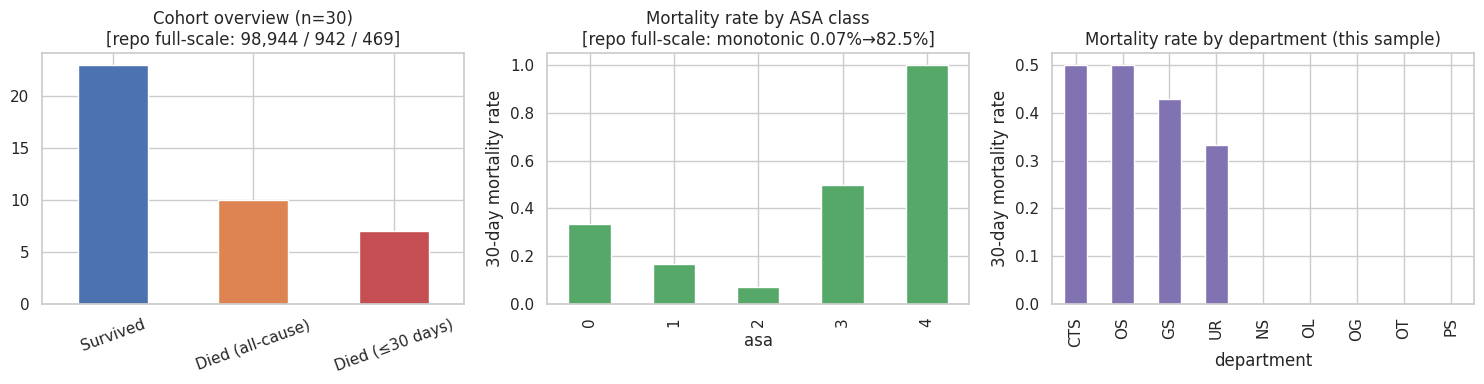

                mean  count
department                 
CTS         0.500000      4
OS          0.500000      2
GS          0.428571      7
UR          0.333333      3
NS          0.000000      3
OL          0.000000      1
OG          0.000000      2
OT          0.000000      5
PS          0.000000      3


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

counts = pd.Series({
    "Survived": (~cohort["died_30day"]).sum(),
    "Died (all-cause)": cohort["died_allcause"].sum(),
    "Died (\u226430 days)": cohort["died_30day"].sum(),
})
counts.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452", "#C44E52"])
axes[0].set_title(f"Cohort overview (n={len(cohort)})\n[repo full-scale: 98,944 / 942 / 469]")
axes[0].tick_params(axis='x', rotation=20)

cohort.groupby("asa")["died_30day"].mean().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Mortality rate by ASA class\n[repo full-scale: monotonic 0.07%\u219282.5%]")
axes[1].set_ylabel("30-day mortality rate")

dept_mortality = cohort.groupby("department")["died_30day"].agg(["mean", "count"])
dept_mortality[dept_mortality["count"] >= 1].sort_values("mean", ascending=False)["mean"]\
    .plot(kind="bar", ax=axes[2], color="#8172B2")
axes[2].set_title("Mortality rate by department (this sample)")
axes[2].set_ylabel("30-day mortality rate")

plt.tight_layout()
plt.show()

print(dept_mortality.sort_values("mean", ascending=False))

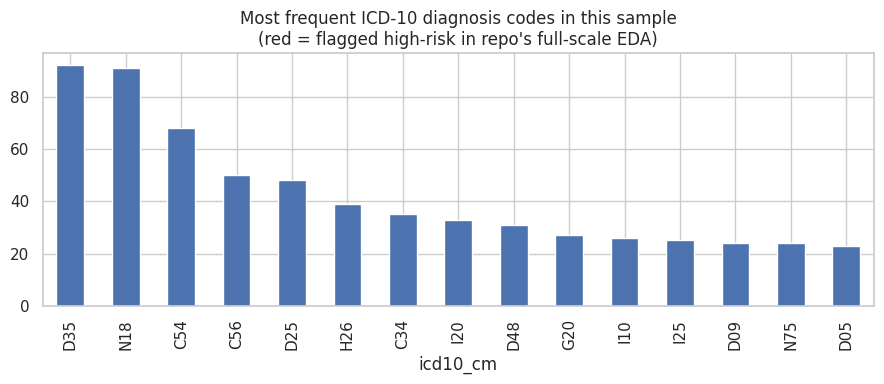

In [7]:
# ICD-10 diagnosis frequency and (small-sample) mortality association.
# On the full dataset the repo found these 6 codes carry by far the strongest signal —
# worth checking they still stand out, or at least appear, on whatever subset you're using:
#   D65 DIC 28.3%   I46 cardiac arrest 26.7%   R57 shock 22.6%
#   J80 ARDS 21.5%  K72 hepatic failure 12.3%  A41 sepsis 9.5%
HIGH_RISK_ICD10 = {"D65", "I46", "R57", "J80", "K72", "A41"}

diag_rows = []
for sid, s in subjects.items():
    died = s.died_30day()
    for d in s.diagnoses:
        diag_rows.append({"subject_id": sid, "icd10_cm": d["icd10_cm"], "died_30day": died})
diag_df = pd.DataFrame(diag_rows)

top_codes = diag_df["icd10_cm"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#C44E52" if c in HIGH_RISK_ICD10 else "#4C72B0" for c in top_codes.index]
top_codes.plot(kind="bar", ax=ax, color=colors)
ax.set_title("Most frequent ICD-10 diagnosis codes in this sample\n(red = flagged high-risk in repo's full-scale EDA)")
plt.tight_layout()
plt.show()

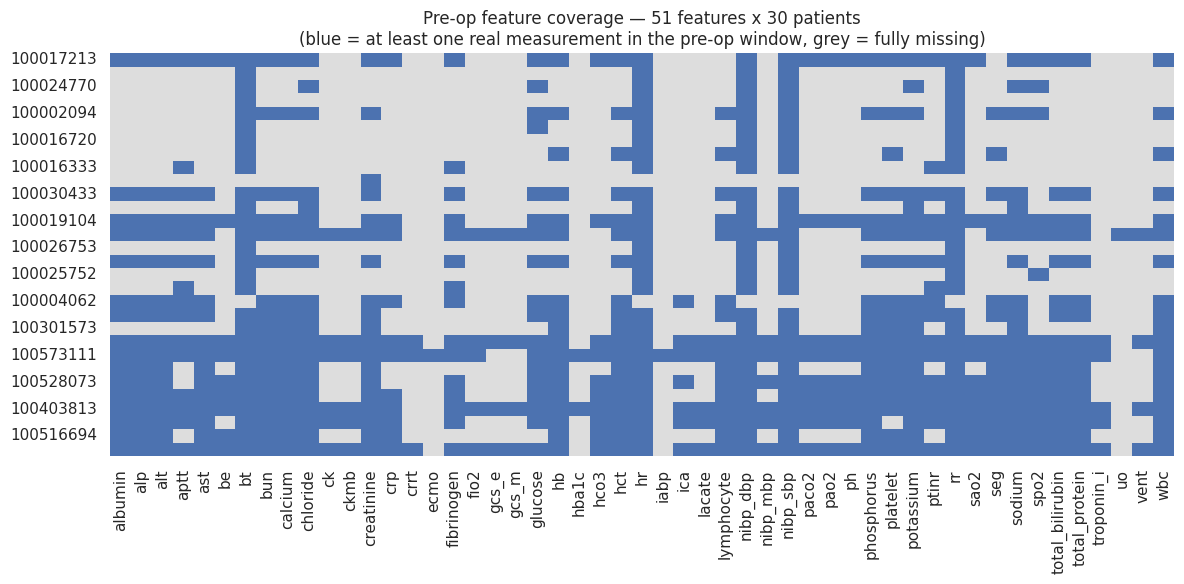

Mean features present per patient (of 51 seen in this sample): 22.8
Min: 1  Max: 47


In [8]:
# Missingness — which of the 54 pre-op-usable features (38 labs + 16 ward vitals)
# does each patient actually have data for, inside the pre-op window?
PREOP_WINDOW_MIN = PREOP_WINDOW_DAYS * 24 * 60

def preop_feature_coverage(s: Subject) -> Dict[str, bool]:
    last_op = s.get_last_operation()
    orin = int(last_op["orin_time"])
    min_t, max_t = orin - PREOP_WINDOW_MIN, orin - 1
    present = set()
    for row in s.get_timeseries_window("labs", min_t, max_t):
        present.add(row["item_name"])
    for row in s.get_timeseries_window("ward_vitals", min_t, max_t):
        present.add(row["item_name"])
    return present

coverage_rows = []
all_features_seen = set()
per_subject_present = {}
for sid, s in subjects.items():
    present = preop_feature_coverage(s)
    per_subject_present[sid] = present
    all_features_seen |= present

all_features_sorted = sorted(all_features_seen)
matrix = pd.DataFrame(
    {sid: [1 if f in per_subject_present[sid] else 0 for f in all_features_sorted]
     for sid in subjects},
    index=all_features_sorted
).T

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(matrix, cbar=False, cmap=["#DDDDDD", "#4C72B0"], ax=ax)
ax.set_title(f"Pre-op feature coverage — {len(all_features_sorted)} features x {len(subjects)} patients\n"
             "(blue = at least one real measurement in the pre-op window, grey = fully missing)")
plt.tight_layout()
plt.show()

completeness = matrix.sum(axis=1)
print(f"Mean features present per patient (of {len(all_features_sorted)} seen in this sample): "
      f"{completeness.mean():.1f}")
print(f"Min: {completeness.min()}  Max: {completeness.max()}")

## Part 4 — Theory + reasoning: the mortality label

This is a genuinely settled question in the uploaded repo (full-scale, 99,886-patient
analysis) — worth restating here because *every* downstream number (`pos_weight`, AUROC,
which patients are "positive") depends on it, and it's a good template for how the
reasoning-before-code pattern in this notebook works.

**The question:** the dataset's own `survived/`/`died/` folder split was built from
`died()` — "died at any point in this hospital record, ever" — not from the project's
actual stated target, "died within 30 days of surgery."

**Three things had to be decided, each with real alternatives:**

| Decision | Options considered | What the full-scale data showed | Choice made |
|---|---|---|---|
| Which mortality definition | All-cause (942 deaths) vs. strict 30-day (469 deaths) | 473 of the 942 "died" patients died 91–242+ days after their last operation — of causes plausibly unrelated to the surgery | **30-day**, because it's the clinically specific question ("did this operation kill this patient"), not "did this patient ever die" |
| Which operation anchors the 30-day window, for multi-operation patients | First operation vs. last operation vs. exclude multi-op patients | Only 111/21,565 multi-op patients get a *different* answer depending on anchor, and the disagreement runs **only one direction** (last-op says died, first-op says survived) — median gap between first and last op for these 111 patients was **11 months**, i.e. old unrelated surgery, not staged procedures | **Last operation**, since an operation 11 months ago that has nothing to do with why a patient is having surgery today shouldn't be the reference point for that (unrelated) death |
| Excluding multi-op patients entirely, for a "cleaner" label | Include vs. exclude | Mortality rises steadily with operation count (0.4% → 0.6% → 1.2% → 1.3%) — multi-op patients are measurably higher-risk, not a random subset | **Include them** — excluding would introduce selection bias, quietly making the remaining cohort look healthier than it is |

**Why walk through this instead of just using the answer:** this is the exact reasoning
pattern to repeat for every other open decision below (missing data, sampling,
architecture) — state the alternatives, state what the data actually shows, and only
then commit, rather than picking the first plausible-sounding method.

**What this notebook implements** (see `died_30day()` above): 30-day mortality, anchored
on the **last** recorded operation. `died_allcause()` is kept alongside it purely as a
diagnostic — to reproduce the mismatch-count sanity check on whatever data you load.

## Part 5 — Theory + reasoning: the organ-system feature architecture

### 5.1 Where the repo already is

The repo has already converged on a **6-system** grouping (renal, cardiovascular,
respiratory, metabolic/hepatic, haematology-coagulation, neurological), and — importantly
— it didn't invent this from nothing. It's grounded in two independent, real clinical
standards that happen to agree with each other:

- **SOFA** (Sequential Organ Failure Assessment, Vincent et al. 1996) — the actual
  clinical gold standard for organ-dysfunction scoring in critically ill patients — scores
  exactly six systems, and *deliberately does not* have a 7th "infection" system.
- **Sepsis-3** (Singer et al. 2016, *JAMA*) defines sepsis as *an infection that triggers
  a SOFA score change* — i.e. infection is a cross-cutting flag layered on top of the six
  systems, not a system of its own.
- Independently, the **WHO ICD-10 chapter structure** also gives infectious disease
  (Chapter A–B) its own dedicated chapter, separate from every organ chapter — a second,
  unrelated line of evidence for the same conclusion.

This notebook keeps that decision (infection/inflammation as a **cross-cutting flag** —
CRP, WBC, temperature, procalcitonin if available — rather than a competing system), and
extends the architecture with what the meeting asked for.

### 5.2 Adding Gastrointestinal as its own system

**The reasoning for splitting it out, not just leaving it under "metabolic/hepatic":**
the repo currently folds ICD-10 chapter K (digestive) in with hepatic labs (AST, ALT,
bilirubin) under one "metabolic/hepatic" bucket. But clinically these are two different
failure modes — liver synthetic/metabolic failure (tracked well by the existing labs) vs.
a mechanical/infective bowel problem (bowel obstruction, ischaemia, perforation,
peritonitis) — and INSPIRE's own worked example patient (Section 6 of the repo's `index.md`)
is a direct illustration: her presenting diagnosis was **K65 (peritonitis)**, a *bowel*
emergency, and her hepatic labs were never flagged as the problem — her renal system was.
Lumping K65 into "metabolic/hepatic" would have hidden the actual reason she was in
theatre in the first place.

**What actually goes into a GI system, given what INSPIRE has:** INSPIRE's 38 labs and 16
ward vitals don't include dedicated GI markers (no amylase, lipase, or bowel-specific
labs) — this is a real, honest limitation, not an oversight in this notebook. So unlike
the other systems, the GI branch is built almost entirely from **diagnosis and procedure
codes**, not continuous physiology:
- ICD-10 diagnosis chapter **K, excluding K70–K77** (which stays hepatic) — bowel
  obstruction, peritonitis, appendicitis, inflammatory bowel disease, GI bleeding, etc.
- ICD-10-PCS procedure body-system letters **D** (gastrointestinal) and **C** (mouth and
  throat, upper GI-adjacent) from `icd10_pcs` on the operations table.
- Cross-linked, general-inflammation labs (CRP, WBC, lactate, temperature) as
  *shared* inputs with the infection flag and the cardiovascular system respectively (see
  5.4) — a GI catastrophe like perforation or ischaemia shows up physiologically as shock
  and inflammation, even though INSPIRE has no bowel-specific lab to see it directly.

This is a real design trade-off worth stating plainly: the GI branch will be the weakest,
sparsest of the systems on this dataset — this is worth flagging as a genuine limitation
rather than a modelling failure once results come in.

### 5.3 Adding Musculoskeletal as its own system

The repo currently treats ICD-10 chapter M (musculoskeletal) as **"frailty-adjacent
only"** — i.e. it feeds into the HFRS frailty score (fracture/osteoporosis codes are part
of Gilbert et al.'s original 109-code list) but has no dedicated branch of its own. The
meeting explicitly asked for it to be promoted to a full system.

**What goes in it:**
- ICD-10 diagnosis chapter **M** — fractures, osteoporosis, osteoarthritis, myopathies.
- ICD-10-PCS procedure body-system letters — the official ICD-10-PCS body-system table
  (2nd character of the procedure code) allocates **K** (muscles), **L** (tendons), **M**
  (bursae/ligaments — a genuine, if confusing, letter collision with the *chapter* letter
  M used above; keep these distinct in code, they mean different things), **N/P/Q**
  (facial/upper/lower bones), **R/S** (upper/lower joints) to musculoskeletal procedures.
  *(Worth verifying this table against the official CMS ICD-10-PCS reference before
  publication — flagged with the same "needs confirming" caution the repo applies to its
  own ICD-10-PCS claims.)*
- Like GI, this branch has no dedicated continuous lab (no CK for muscle breakdown is in
  the 38-lab list either, though **CK/CK-MB exist and are currently assigned to
  cardiovascular** — worth a joint check once real data volume exists, since CK is not
  cardiac-specific).

**Why this is worth doing even though the sample data has a handful of MSK operations:**
in the 30-patient sample already loaded above, `0SBA0` (lower joints) and `0NSB3` (facial
bones) both appear as real procedure codes — i.e. the signal exists in this dataset even
at tiny scale, it's just never had a dedicated branch to flow into.

### 5.4 Cardiovascular parameters in the renal system — the cardio-renal coupling

This is the most clinically substantive addition from the meeting, and it deserves more
than "just put HR and BP features in both branches."

**The clinical grounding:** this is a well-established, named phenomenon —
**cardiorenal syndrome** (Ronco et al. 2008, *Journal of the American College of
Cardiology* — "Cardiorenal Syndrome," a widely cited classification into five types).
The core idea: the heart and kidneys regulate each other's function through shared
haemodynamics (cardiac output drives renal perfusion; fluid overload from renal failure
increases cardiac preload) — dysfunction in one organ **directly and bidirectionally**
worsens the other, not just correlates with it via a shared risk factor. This is exactly
the "renal directly proportionate to cardiovascular" framing from the meeting, and it has
a name and a real classification system in the nephrology/cardiology literature:

| Type | Direction |
|---|---|
| Type 1 (acute cardiorenal) | Acute heart failure → acute kidney injury |
| Type 2 (chronic cardiorenal) | Chronic heart failure → progressive chronic kidney disease |
| Type 3 (acute renocardiac) | Acute kidney injury → acute cardiac dysfunction |
| Type 4 (chronic renocardiac) | Chronic kidney disease → cardiac dysfunction |
| Type 5 (secondary) | A systemic condition (e.g. sepsis) causes both simultaneously |

**Why this matters architecturally, not just as a citation:** if the renal and
cardiovascular branches are trained as two fully independent encoders and only meet at
the final concatenation layer, the model has no way to represent "this patient's renal
decline is *because of* their cardiac state" — it can only represent "these two things
both happened to be abnormal." A plain concatenation treats the two systems as
conditionally independent given the outcome, which the cardiorenal-syndrome literature
says is specifically wrong for this pair of organs.

**Architectural choice made here (see Part 9 for the full multimodal design):**
1. The renal encoder is given the standard renal panel (creatinine, BUN, sodium,
   potassium, chloride, calcium, phosphorus, `crrt`, `uo`) **plus** a small set of
   cardiovascular features known to drive renal perfusion (mean arterial pressure /
   `nibp_mbp`, heart rate) — i.e. cardiovascular parameters genuinely are added into the
   renal input set, exactly as asked.
2. Separately, after both branches produce their own embeddings, an explicit
   **renal↔cardiovascular cross-attention/gating term** is added before the final fusion
   (Part 9.3) — so the *interaction* between the two systems' embeddings, not just their
   independent existence, is a first-class part of the architecture. This is the part a
   plain "share some features" approach would miss.

### 5.5 The full, extended system taxonomy used in this notebook

| System | Labs | Ward vitals | ICD-10 chapter(s) | ICD-10-PCS body-system letter(s) | Notes |
|---|---|---|---|---|---|
| **Renal** | creatinine, bun, sodium, potassium, chloride, calcium, phosphorus, ica | crrt, uo | N | T | + shared CV inputs (5.4) |
| **Cardiovascular** | troponin_i, troponin_t, ck, ckmb, lactate | hr, nibp_sbp, nibp_dbp, nibp_mbp, iabp | I | 2,3,4,5,6 | lactate moved here per repo's literature review (perfusion marker) |
| **Respiratory** | ph, pao2, paco2, hco3, sao2, be | spo2, rr, fio2, vent, ecmo | J | B | |
| **Metabolic / Hepatic** | glucose, albumin, ast, alt, total_bilirubin, alp, total_protein, hba1c | bt | E, K70–K77 | F, G | hepatic labs kept here, hepatic *disease* (K70-77) kept here too |
| **Haematology / Coagulation** | hb, hct, wbc, platelet, ptinr, aptt, fibrinogen, d_dimer, crp, lymphocyte, seg | — | D50–D89 | 7 | |
| **Neurological** | — | gcs_e, gcs_m, gcs_v | G | 0, 1 | |
| **Gastrointestinal (NEW)** | *(shares crp, lactate — see 5.2)* | — | K (excl. K70–77) | D, C | sparsest branch — code-driven, not lab-driven |
| **Musculoskeletal (NEW)** | *(shares ck — provisional)* | — | M | K, L, M, N, P, Q, R, S | promoted from frailty-only to full branch |
| **Infection / inflammation** *(cross-cutting flag, not its own encoder)* | crp, wbc | bt | A, B | — | per SOFA/Sepsis-3 — feeds every branch as context, not a competing system |

**Longer-term path for ICD-10, once this proof-of-concept is validated:** the repo's own
research doc recommends moving from hand-rolled chapter letters to **AHRQ/HCUP's CCSR**
(Clinical Classifications Software Refined) — 530+ clinically meaningful categories
across 21 body systems, free and government-maintained — as a more authoritative,
higher-resolution replacement for the chapter-letter mapping used here. This notebook
uses the chapter-letter approach because it's a fast, auditable, zero-dependency
starting point; the code is structured so `icd10_to_systems()` (Part 10) is the one
function to swap out for a CCSR lookup later.

## Part 6 — Theory + reasoning: operation history, washout rules, and pre/intra/post-op windows

### 6.1 "Number of operations in the same area matters" — designing the feature properly

The repo's own full-scale analysis already confirms the *raw* version of this: mortality
climbs from 0.4% (1 op) to 1.3% (4 ops) with total operation count. But the meeting note
is more specific — *same area* matters, not just *any* prior operation. A patient with
four unrelated minor day-procedures over a decade is a different risk profile than a
patient with three operations on the same organ system in the last year (repeat
interventions, staged procedures for cancer, complications requiring reoperation).

**Design:** use the ICD-10-PCS body-system letter (Part 5.5's mapping, 2nd character of
`icd10_pcs`) as the "area." For each operation, compute, using only operations *before*
it in time (no future leakage):
- `n_prior_ops_same_area` — count of previous operations sharing the same body-system letter
- `n_prior_ops_any_area` — total previous operation count (the repo's existing signal)
- `days_since_last_op_same_area` — recency, since a same-area operation 8 years ago is
  clinically very different from one 3 weeks ago, even though both count as "1 prior op,
  same area"

### 6.2 The cardiovascular washout exception — "wait 6 months after cardiac surgery"

This rule doesn't exist anywhere in the current codebase — it's genuinely new domain
knowledge from the meeting, so it's worth being explicit about the clinical reasoning
before encoding it as a feature, rather than treating it as an arbitrary threshold.

**Why 6 months, clinically:** after cardiovascular surgery (especially anything involving
cardiopulmonary bypass — `cpbon_time`/`cpboff_time` are already tracked per-operation in
INSPIRE), the heart and the coagulation system are in a genuinely different physiological
state for a meaningful recovery period — myocardial remodelling, ongoing anticoagulation
management, healing of vascular anastomoses. A second operation, of any kind, inside that
window carries elevated risk **specifically because of the recent cardiac surgery**, not
just because "recent surgery in general is risky" (which the `n_prior_ops`/recency
features above already capture more generally). This is the same logic as
drug-interaction washout periods in pharmacology — enough physiological time must pass
before the system is back to a comparable baseline.

**Feature design (implemented in Part 10):**
- `days_since_last_cardiac_op` — time since the most recent operation with body-system
  letter in `{2,3,4,5,6}` (heart/great vessels/arteries/veins) or department `CTS`
- `cardiac_washout_violated` — binary flag, `True` if the current operation occurs **less
  than `CARDIAC_WASHOUT_DAYS` (180) days** after a prior cardiovascular operation
- This is deliberately built as a *general mechanism* (`get_washout_flag(system, days)`)
  rather than a hardcoded one-off, so the same pattern can express other clinically known
  exceptions if the team identifies more of them later (e.g. a analogous window after
  major GI resection, or after a transplant) — a single reusable feature-engineering
  primitive rather than one bespoke column.

**Honest caveat to raise with the clinical team, not just note internally:** the exact
window (180 days) is what was reported at the meeting, but the repo's own established
pattern for taking a clinical rule at face value is to state it, test it against the
data, and get it validated — the Clinician_Questions.md doc in the existing repo runs
exactly this pattern for ASA/POSSUM/NELA. The same "test empirically, then confirm with a
clinician" step is worth applying here too: once real volume of cardiac-then-reoperation
cases exists, check whether outcomes for the <180-day group are actually measurably worse
than the ≥180-day group, and whether 180 is the threshold the data itself would suggest,
or just the round number that's easiest to state in a meeting.

### 6.3 Pre-operative, intra-operative, post-operative — three windows, not pooled together

This is already a well-reasoned open question in the repo (`Research_Aim.md` §2.6): three
genuinely different windows exist in every INSPIRE record, and each answers a different
clinical question:

```
[admission=0] ... [orin_time] ── surgery ── [orout_time] ... [discharge_time]
     └── pre-op window ──┘                      └── post-op window ──┘
                    └── intra-op window (orin_time → orout_time) ──┘
```

| Window | What it captures | What kind of tool it makes |
|---|---|---|
| **Pre-operative** | Baseline chronic state — how sick the patient already was | Decision-support ("should we operate, should ICU be pre-booked") |
| **Intra-operative** | Acute physiological stress response — blood loss, BP instability, anaesthesia duration | Real-time monitoring ("should the team escalate mid-case") |
| **Post-operative (early)** | Recovery vs. deterioration trajectory | Early-warning/rescue ("flag this patient before a formal deterioration event") |

**Decision made for this notebook:** rather than picking one window and assuming it's
right (an assumption the repo's own docs explicitly warn against), **keep all three as
separate, labelled feature blocks** per organ system, and let the per-system encoders
(Part 9) see all three windows as distinct channels. This directly supports the "pre,
intra, post all important to understand" instruction from the meeting — it's implemented
as a design choice (three parallel time blocks per system, not a single pooled window),
not asserted as a claim. A useful, cheap experiment once training is running: mask out
each window one at a time and see how much AUROC drops — a direct, empirical answer to
"how much is each window actually contributing," extending the repo's own EDA finding
that intra-op vitals are *systematically less missing* than the same measurements taken
on the ward (monitors are physically attached during surgery), which is a data-quality
reason a peri-operative model might out-perform a pre-op-only one, separate from any
genuinely new physiological information intra-op data carries.

**One caution applied consistently:** the *post-operative* window must stop well before
`discharge_time`/any later diagnosis that is a *consequence* of the outcome being
predicted, to avoid leaking information about the outcome into a feature meant to predict
it. This notebook caps the post-op window at `POSTOP_WINDOW_DAYS` (default 3 days) from
`orout_time` — short enough to capture early recovery trajectory without reaching into
the territory of "the patient is already coding, of course the model can tell they'll die."

## Part 7 — Theory + reasoning: missing data handling

### 7.1 First, classify *why* the data is missing — this determines which methods are even valid

The foundational framework here is **Rubin (1976)**, "Inference and Missing Data,"
*Biometrika* — still the standard reference for this three-way classification:

| Mechanism | Definition | Does INSPIRE show this pattern anywhere? |
|---|---|---|
| **MCAR** — Missing Completely At Random | Missingness is unrelated to any observed or unobserved value | Rare in real clinical data; not the dominant pattern here |
| **MAR** — Missing At Random | Missingness depends on *observed* data, not the missing value itself | Plausible for some labs — e.g. a department's routine order-set determines what gets tested, and department is observed |
| **MNAR** — Missing Not At Random | Missingness depends on the *unobserved value itself*, or on something unmeasured | The repo's own EDA flags exactly this hypothesis directly: `spo2` coverage is 93% "anywhere in the record" but drops to 40% in the pre-op window specifically because monitors get attached once a patient is already admitted/in theatre — the *reason* it's missing (not yet monitored) is entangled with *how sick the patient is right now* |

**Why this matters practically, not just as terminology:** if missingness is MNAR — a
clinician's decision *not* to order a test because the patient looked well enough not to
need it — then the fact that a value is missing is itself informative about the outcome,
and naively filling it in (even with a very good imputation model) throws that signal
away. This is exactly the "treat missingness as a signal, not just noise" hypothesis the
repo's own roadmap already flags as worth testing directly against its missingness
heatmap.

### 7.2 The candidate methods, in order of sophistication

| Method | How it works | Strength | Weakness for this dataset |
|---|---|---|---|
| **Listwise/pairwise deletion** | Drop rows/columns with any missing value | Simple, no bias if truly MCAR | Would discard almost every patient — mean pre-op coverage is 22.6/54 features (repo's audit), so this is not viable here |
| **Mean/median imputation** | Fill with the population (or per-department) mean/median | Fast, simple baseline | Silently shrinks variance, and — per 7.1 — actively destroys the MNAR signal if missingness itself carries information |
| **Last-observation-carried-forward (LOCF)** | Fill forward from the most recent real value | Reasonable for slowly-changing labs | Wrong assumption for acutely deteriorating patients — exactly the ones this model most needs to get right |
| **Linear interpolation** *(the repo's current approach)* | Draw a straight line between the two nearest real observations | Simple, preserves some local trend, already implemented and validated in `align_time_series()` | Assumes smooth monotonic change between samples — a poor assumption across a long gap where the true trajectory may have spiked and returned (e.g. this exact patient's glucose: 78 → 264 → 84 across ~25 minutes, Part 6 of the repo's `index.md`) |
| **Regression / KNN imputation** | Predict the missing value from other observed features/patients | Uses cross-feature correlation (e.g. the correlation heatmap already built in the repo's EDA) | Assumes MAR; doesn't use the *time* dimension explicitly |
| **MICE** (Multiple Imputation by Chained Equations, Van Buuren & Groothuis-Oudshoorn 2011) | Iteratively models each feature as a function of all others, repeated across multiple imputed datasets | Statistically principled, gives you an uncertainty estimate across the multiple imputations | Computationally heavier; still fundamentally a MAR-style method |
| **Deep generative imputation** (e.g. **GAIN** — Yoon et al. 2018, *ICML*, "GAIN: Missing Data Imputation using Generative Adversarial Nets") | A GAN where the generator fills gaps and the discriminator tries to tell which values were real vs. imputed | State of the art for complex, high-dimensional missingness patterns | Needs a lot of data to train reliably — not realistic on a 30-patient dev sample, worth revisiting only once the full ~99,886-patient dataset is in scope |
| **Missingness-as-a-feature (mask channels)** *(already in the repo's pipeline)* | Keep an explicit binary "was this value observed or imputed" column alongside every feature | Directly encodes the MNAR hypothesis instead of discarding it — the model can learn "creatinine is missing" is itself informative | Doubles the feature count; needs enough data for the mask channel to be learnable, which is exactly the class-imbalance problem in Part 8 |
| **Masked/contrastive self-supervised pre-training** (BERT-style masking, or the masked-value objective already proposed in the repo's roadmap as a fix for the "encoder just predicts 0.47 for everyone" failure mode) | Pretrain the encoder to predict a deliberately masked-out real value from surrounding context, on the *entire unlabelled cohort* | Directly uses the largest available signal (99,886 patients, unlabelled) rather than the tiny labelled subset; naturally handles irregular sampling | More complex to implement and validate than the simpler options above |

### 7.3 The choice made for this notebook, and why

**Decision: linear interpolation + explicit mask channels (repo's existing approach,
kept), with median imputation used only as the fallback for features that have *zero*
observations for a given patient** (rather than filling the whole column with `0.0`,
which the repo's own audit flagged as a real bug — a raw `0.0` becomes a fixed non-zero
number after `StandardScaler`, i.e. a phantom "measurement" the model can't distinguish
from a real low value except via the mask channel).

**Reasoning, laid out explicitly rather than asserted:**
1. Given the data volume available right now (30-patient dev sample), MICE and GAIN are
   both **not yet appropriate** — they need enough rows to learn a reliable
   cross-feature or generative model, and would likely just overfit to sampling noise on
   this subset. This is a decision that should be **revisited once the full dataset is
   mounted** — GAIN in particular is worth a real experiment at full scale, given how
   directly it targets the MNAR problem this dataset plausibly has.
2. Keeping the **mask channel** is non-negotiable regardless of which fill method is
   chosen, precisely because of the MNAR hypothesis in 7.1 — losing "was this observed"
   loses real signal, not just uncertainty bookkeeping.
3. Median imputation (population-level, computed on the **training fold only** to avoid
   leakage) replaces the "zero-fill" bug rather than pretending it's a robust general
   solution — it is a deliberately modest fix to a known correctness problem, not a claim
   that median-fill is the right long-term missing-data strategy.
4. The **masked-value pre-training objective** is flagged here as the recommended next
   experiment once the full cohort is available — it's the one approach on this list that
   turns "we have very few labelled deaths" from a pure liability into an opportunity
   (99,886 unlabelled patients to pretrain on), and it's already partially compatible
   with the repo's existing two-phase (pretrain → fine-tune) pipeline design.

## Part 8 — Theory + reasoning: class imbalance and sampling

### 8.1 The scale of the problem

469 deaths out of 99,886 patients under the correct 30-day definition — **0.47%**
mortality, `pos_weight ≈ 211`. This is not a mild imbalance; it's the kind of ratio where
a model that predicts "survived" for every single patient scores 99.5% "accuracy" while
being clinically useless — which is exactly why the repo already tracks AUROC/AUPRC
rather than accuracy, and why this section matters more than it might for a more balanced
problem.

### 8.2 The candidate methods

| Method | How it works | Strength | Risk specifically for THIS dataset |
|---|---|---|---|
| **Random oversampling** | Duplicate minority-class examples until balanced | Trivial to implement | With time-series patients, duplicating a positive patient's *entire sequence* risks the model memorizing that one patient rather than learning generalisable patterns — especially dangerous with only 469 unique positive patients total |
| **Random undersampling** | Drop majority-class examples until balanced | Fast, cheap | Throws away real information — with 98,944 survivors, undersampling to match 469 deaths discards >99% of the negative class's diversity |
| **SMOTE** (Chawla et al. 2002, *JAIR*) | Generates synthetic minority examples by interpolating between real minority points in feature space | Better than naive duplication — creates genuinely new points, not copies | SMOTE was designed for static tabular features; interpolating between two *different patients'* full time series (different lengths, different missingness patterns) doesn't produce a physiologically coherent patient — this is a real, known limitation of applying SMOTE to raw sequential data, not a theoretical nitpick |
| **ADASYN** (He et al. 2008) | Like SMOTE, but generates more synthetic points near the decision boundary (harder-to-classify minority examples) | Focuses effort where it's most needed | Same sequential-data caveat as SMOTE |
| **Cost-sensitive loss / `pos_weight`** *(already in the repo's pipeline)* | Weight the minority class's loss contribution higher, without touching the data itself | No synthetic data risk at all — the model just gets penalised more for missing a death | Needs the weight tuned carefully; too aggressive a weight can push the model toward over-predicting death, hurting calibration (Part 12) |
| **Focal loss** (Lin et al. 2017, *ICCV*, "Focal Loss for Dense Object Detection") | Down-weights easy, already-well-classified examples, focusing training on hard/rare cases | A more adaptive version of cost-sensitive weighting — doesn't need a single fixed `pos_weight`, adjusts per-example | An extra hyperparameter (focusing parameter γ) to tune; worth comparing directly against plain `pos_weight` rather than assuming it's automatically better |
| **Generative synthetic data** (GANs, VAEs, diffusion models; tabular-specific variants like CTGAN) | Train a generative model on real minority examples, sample new synthetic ones | Can in principle generate more realistic synthetic patients than SMOTE's linear interpolation | With only 469 real positive patients (and fewer once split into train/val/test), there isn't enough data to train a reliable *generative* model without it just memorising/reproducing the training examples — the exact opposite of what's needed |
| **Stratified splitting** *(a prerequisite, not an alternative to any of the above)* | Ensure every train/val/test fold preserves the true ~0.5% mortality rate | Prevents an unlucky split from producing a test fold with 0 or 1 positive case (the repo's own runs show AUROC swinging by ±0.1–0.2 purely from a 6–10-patient test fold) | Not itself a class-imbalance fix — this handles *evaluation* stability, separate from *training* strategy |

### 8.3 The choice made for this notebook, and why

**Decision: cost-sensitive loss (`pos_weight` in `BCEWithLogitsLoss`, matching the repo's
existing approach) as the primary strategy, plus mandatory stratified k-fold splitting.
SMOTE/ADASYN are implemented but scoped to the *static* feature block only (age, ASA,
operation-history features), never applied to raw time-series sequences.**

**Reasoning:**
1. **Cost-sensitive loss doesn't fabricate any data**, which matters a lot here — with
   only 469 real positive patients at full scale, and a lot riding on the model actually
   learning real physiological patterns (not artifacts of interpolation between two
   different patients' sequences), the safest default is to not touch the minority
   examples at all and instead change how much the loss function cares about getting them
   right.
2. **SMOTE is kept as an available, explicitly scoped tool** — because it may still be
   useful *specifically* on the static per-patient feature block (age, ASA, operation
   counts, HFRS score — all fixed-length vectors, no time dimension, no sequence-length
   mismatch problem), where the "interpolating between two different patients"
   objection doesn't apply the same way. This notebook keeps SMOTE off the time-series
   branches by construction, not by assumption.
3. **Generative synthetic patient data (GANs/VAEs) is flagged as a genuinely interesting
   longer-term direction, explicitly not attempted here** — 469 positive examples (and a
   fraction of that after splitting) is not enough to trust a generative model not to
   just memorise, and the repo's own roadmap lists this as a "candidate to evaluate," not
   a settled choice — this notebook treats it the same way: worth a dedicated experiment
   once more labelled data exists (or via transfer from a larger public perioperative
   cohort), not a default.
4. **Focal loss is implemented as an easy A/B comparison against `pos_weight`**, since it's
   a small code change and directly answers a fair question: does adaptively focusing on
   hard examples out-perform a single fixed weight, on *this* dataset specifically, rather
   than assuming the literature's general finding transfers automatically.
5. Regardless of which loss weighting is used, **AUROC and AUPRC are reported together**
   (as the repo already does) and **calibration is checked separately** (Part 12) — a
   `pos_weight` chosen to maximise AUROC can quietly wreck calibration by systematically
   over-predicting risk, which matters if the output is ever shown to a clinician as an
   actual probability.

## Part 9 — Theory + reasoning: the multimodal DNN architecture

### 9.1 The core idea, and why it's not just "one bigger model"

The repo's current pipeline is a single transformer over 7 pooled features → one 14-dim
embedding → one sigmoid. It works, but it's a black box: nothing in the architecture
*forces* the model to organise what it's learned by physiological system, so there's no
principled way to ask "why did it predict high risk for this patient" beyond post-hoc
methods like SHAP — which, on correlated, temporally-dependent clinical features, are
known to give unstable, sometimes misleading approximations (they fit a separate simple
model around the trained network, after the fact; they don't reveal what it actually
computed).

**The alternative pursued here — interpretability built into the architecture, not
explained after the fact:** train **one small encoder per organ system** (the 8-system
taxonomy from Part 5), each seeing only that system's inputs, each producing its own
named embedding. A downstream classifier then combines these named embeddings — so
"renal: critical, GI: concern, cardiovascular: ok" is a real decomposition of what the
network computed, not a story told about a finished black box.

### 9.2 Building block 1 — the per-system time-series encoder

Each system's inputs are irregular-interval clinical time series (labs/vitals), exactly
the shape the repo's existing `TimeSeriesTransformer` already handles. Two realistic
choices for the encoder itself:

| Encoder | How it works | Pros | Cons |
|---|---|---|---|
| **Small Transformer** (repo's current choice) | Self-attention over the time steps in the window, positional encoding | Handles long-range dependencies well, attention weights are themselves inspectable (Part 13) | More parameters, needs more data to train well per branch — a real concern once splitting the already-small labelled set eight ways |
| **GRU** (Gated Recurrent Unit) | Recurrent processing, one time step at a time | Far fewer parameters, well-suited to shorter/sparser per-system sequences (e.g. the GI branch, which may have very few real observations) | Sequential processing — no direct attention-based interpretability, though hidden-state trajectories can still be inspected |

**Decision for this notebook:** use a small **GRU** as the default per-system encoder,
not the repo's Transformer, specifically because of the branch-splitting concern above —
eight branches sharing an effective sample size of hundreds of positive labels each is a
much higher risk of under-fitting a full transformer per branch than fitting one shared
7-feature transformer. This is implemented as a swappable `encoder_type` argument
(`'gru'` or `'transformer'`), so the transformer variant is a one-line experiment once
more data is available, not a rewrite. Sparse branches (GI, musculoskeletal) in
particular are expected to benefit from the lower parameter count of a GRU.

### 9.3 Building block 2 — fusion strategies, and the cardio-renal coupling term

Three fusion strategies, in increasing order of how much genuine interpretability they add
(not just complexity):

1. **Early concatenation** — stack every system embedding into one vector, one final
   `Linear` classifier. Simplest, but *no more interpretable* than the current single
   model — you can't attribute the final score back to any one system cleanly, because
   the classifier's weights mix everything together.
2. **Gated / mixture-of-experts fusion** — a small gating network learns, per patient, how
   much weight to give each system's embedding. The gate itself is inspectable ("70% of
   this patient's risk score weight came from the renal branch") — a real step up for
   modest extra complexity.
3. **Hierarchical / additive fusion (Neural Additive Model style)** — each system produces
   its own separately-plottable contribution to the final logit, so the *shape* of each
   system's effect on risk can be visualised on its own, closest to genuinely earning the
   word "clinically interpretable."

**Decision for this notebook:** implement **gated fusion** (option 2) as the default —
it's the best complexity-to-interpretability trade-off to build and validate first, with
a clear upgrade path to the additive/NAM version (option 3) once the gated version is
working and validated, rather than trying to build the most sophisticated version first
and risk debugging three new ideas (system-splitting, gating, and additive-shape-functions)
simultaneously.

**The cardio-renal coupling term (Part 5.4), concretely:** after the renal and
cardiovascular encoders each produce an embedding, a small bilinear interaction layer
computes `renal_emb @ W @ cardio_emb.T` (a learned interaction score) and feeds this as an
**additional input to the gate**, alongside the two embeddings themselves — i.e. the model
explicitly has access to "how much do this patient's renal and cardiac states interact,"
not just each one independently. This is a direct, minimal implementation of the
cardiorenal-syndrome reasoning from Part 5.4: it is genuinely different from just
concatenating the two embeddings, because it can express "both are moderately abnormal
AND they're abnormal in a jointly-consistent way" as a distinct signal from "both happen
to be moderately abnormal but unrelated."

### 9.4 Building block 3 — static and categorical inputs

Not every input is a time series. Three genuinely different data types, each needing its
own encoder rather than being forced into the time-series shape:

| Modality | Data type | Encoder |
|---|---|---|
| Static demographic/operative (age, sex, ASA, `emop`, department, operation-history features from Part 6) | Fixed-size vector, 100% coverage | Small MLP |
| ICD-10 diagnosis codes | Categorical, variable-length per patient | Multi-hot chapter-level features now (Part 5.5); a genuine **learned embedding table** is the natural upgrade |
| Medications (ATC codes) | Categorical, timestamped sequence | Not built in this notebook (out of scope for this pass) but designed for the same embedding-table pattern |

**On ICD-10 embeddings specifically — the literature, since this was explicitly asked
for:**
- **Simplest (what this notebook implements):** chapter-level multi-hot / count features
  — fast, interpretable, but treats "acute kidney failure" (N17) and "chronic kidney
  failure" (N18) as unrelated categories.
- **Better — learned code embeddings:** Choi et al. 2016, "Multi-layer Representation
  Learning for Medical Concepts" (**Med2Vec**), *KDD* — a Word2Vec-style embedding trained
  on co-occurring diagnosis codes across the whole (unlabelled) cohort, producing a dense
  vector per code.
- **Most sophisticated, and directly relevant to this dataset's sparse-code problem:**
  Choi et al. 2017, "GRAM: Graph-based Attention Model for Healthcare Representation
  Learning," *KDD* — represents each code as an attention-weighted combination of its
  *ancestors* in the ICD-10 hierarchy, so a rare, sparsely-observed code can still borrow
  signal from its broader chapter. The repo's own audit found genuinely sparse codes (e.g.
  a narrow sepsis-code range at 0.3% coverage) — precisely the situation GRAM was
  designed for.
- **For later interpretability work specifically:** Choi et al. 2016, "RETAIN: An
  Interpretable Predictive Model for Healthcare using Reverse Time Attention Mechanism,"
  *NeurIPS* — two-level attention showing which past visits *and* which codes within them
  most influenced a prediction.

**Decision for this notebook:** implement the chapter-level multi-hot features now (fast,
zero-dependency, immediately usable at any data scale), and structure the code so a
learned embedding table is a drop-in replacement (`icd10_features()` in Part 10 returns a
fixed-width vector either way) — Med2Vec/GRAM are flagged as the concrete next
experiment once enough unlabelled data volume exists to train them properly.

### 9.5 Pre-training — using the unlabelled majority properly

With ~469 labelled positive cases out of 99,886 patients, the single largest source of
information in this dataset is the **unlabelled structure of the time series itself** —
worth treating pre-training as the primary event, not a preliminary step, exactly as the
repo's own roadmap concludes. Three pre-training objectives, compatible with the
per-system-encoder design:

| Objective | Idea | Status |
|---|---|---|
| **Plain reconstruction (autoencoding)** *(repo's current approach)* | Predict the input from a compressed embedding | Already implemented and validated in the repo; known limitation — reconstruction and mortality-discrimination are different objectives, which is part of why the repo saw a "predicts 0.47 for everyone" failure mode before unfreezing the encoder |
| **Masked-value prediction (BERT-style)** | Mask a real observation, predict it from surrounding context | Known to transfer better to downstream discriminative tasks than plain autoencoding; also a natural fit for the missing-data problem in Part 7 |
| **Contrastive pre-training** | Pull same-outcome patients' embeddings closer together, push different-outcome patients apart | Directly optimises for the property the final classifier needs (separable embeddings by outcome), at the cost of needing labels during "pre-training," which partially undercuts the "use the unlabelled majority" argument — worth trying, but as a secondary comparison, not the primary strategy |

**Decision for this notebook:** implement plain reconstruction pre-training (matching the
repo's existing, validated approach) as the default for each per-system encoder, with the
masked-value objective flagged as the concrete next experiment once running at full
scale — it's a small code change (mask random time steps instead of reconstructing
everything) with a real literature-backed reason to expect it to help.

### 9.6 Concept bottleneck — a further interpretability layer, out of scope for the working code in this pass

The repo's stated long-term interpretability goal — model predicts named clinical
concepts (AKI stage via KDIGO criteria, haemodynamic instability, respiratory failure
stage via Berlin criteria) *before* predicting mortality, so the final prediction is
*read off* those concepts rather than an opaque embedding — is the natural next layer on
top of the gated-fusion architecture built here (Koh et al. 2020, "Concept Bottleneck
Models," ICML). It's flagged here as the recommended Part 14 next step rather than
implemented in this pass, since it needs clinician-confirmed staging thresholds
(Section 7 of the repo's `Clinician_Questions.md`) that aren't yet settled.

## Part 10 — Building the feature tables (code)

Implements the decisions from Parts 5–8: the 8-system taxonomy (with the new GI and
musculoskeletal branches, and the renal↔cardiovascular shared inputs), the operation-
history / washout features, the three time windows, and the interpolation + mask
missing-data strategy.

In [9]:
# ── 10.1 Organ-system taxonomy (Part 5.5) ───────────────────────────────────
# Labs / ward_vitals feature lists per system, PLUS the icd10 chapter / icd10-pcs
# body-system-letter rules used to route diagnosis and procedure codes.
#
# NOTE on the renal <-> cardiovascular coupling (Part 5.4): 'nibp_mbp' and 'hr' are
# deliberately listed under BOTH renal and cardiovascular. This is not a bug —
# it is the "cardiovascular parameters added to the renal system" instruction from
# the meeting, implemented directly at the input-feature level. The *learned*
# cross-system interaction term is added later, in Part 11 (RenalCardiacCoupling).

ORGAN_SYSTEMS = {
    "renal": {
        "labs": ["creatinine", "bun", "sodium", "potassium", "chloride", "calcium", "phosphorus", "ica"],
        "ward_vitals": ["crrt", "uo", "nibp_mbp", "hr"],   # last two shared with cardiovascular, see note above
        "icd10_chapters": {"N"},
        "pcs_letters": {"T"},
    },
    "cardiovascular": {
        "labs": ["troponin_i", "troponin_t", "ck", "ckmb", "lacate"],
        "ward_vitals": ["hr", "nibp_sbp", "nibp_dbp", "nibp_mbp", "iabp"],
        "icd10_chapters": {"I"},
        "pcs_letters": {"2", "3", "4", "5", "6"},
    },
    "respiratory": {
        "labs": ["ph", "pao2", "paco2", "hco3", "sao2", "be"],
        "ward_vitals": ["spo2", "rr", "fio2", "vent", "ecmo"],
        "icd10_chapters": {"J"},
        "pcs_letters": {"B"},
    },
    "metabolic_hepatic": {
        "labs": ["glucose", "albumin", "ast", "alt", "total_bilirubin", "alp", "total_protein", "hba1c"],
        "ward_vitals": ["bt"],
        "icd10_chapters": {"E"},           # K70-K77 (hepatic disease) handled specially, see classify_icd10_chapter
        "pcs_letters": {"F", "G"},
    },
    "haematology": {
        "labs": ["hb", "hct", "wbc", "platelet", "ptinr", "aptt", "fibrinogen", "d_dimer", "crp", "lymphocyte", "seg"],
        "ward_vitals": [],
        "icd10_chapters": set(),           # D50-D89, handled specially (needs the numeric sub-range)
        "pcs_letters": {"7"},
    },
    "neurological": {
        "labs": [],
        "ward_vitals": ["gcs_e", "gcs_m", "gcs_v"],
        "icd10_chapters": {"G"},
        "pcs_letters": {"0", "1"},
    },
    "gastrointestinal": {          # NEW — Part 5.2
        "labs": ["crp", "lacate"],  # shared inflammation/perfusion markers; GI has no dedicated lab in INSPIRE
        "ward_vitals": [],
        "icd10_chapters": set(),   # K, EXCLUDING K70-77 -- handled specially
        "pcs_letters": {"D", "C"},
    },
    "musculoskeletal": {           # NEW — Part 5.3
        "labs": ["ck"],            # provisional / shared with cardiovascular -- worth re-checking at scale
        "ward_vitals": [],
        "icd10_chapters": {"M"},
        "pcs_letters": {"K", "L", "M", "N", "P", "Q", "R", "S"},
    },
}
SYSTEM_NAMES = list(ORGAN_SYSTEMS.keys())

# Infection/inflammation is a CROSS-CUTTING FLAG, not its own encoder (Part 5.1, per SOFA/Sepsis-3)
INFECTION_LABS = ["crp", "wbc"]
INFECTION_WARD_VITALS = ["bt"]


def classify_icd10_chapter(code: str) -> set:
    '''Maps one ICD-10-CM diagnosis code to the organ system(s) it belongs to,
    using the WHO chapter structure (Part 5) with the two meeting-requested
    additions (GI split from hepatic, MSK promoted to its own system) and the
    repo-documented fixes (R57 shock -> cardiovascular, lactate-style perfusion
    logic does not apply to codes, only labs).'''
    if not code:
        return set()
    code = code.upper().strip()
    letter = code[0]
    try:
        number = int(code[1:3])
    except (ValueError, IndexError):
        number = None

    systems = set()
    if letter in ("A", "B"):
        systems.add("infection")
    elif letter == "E":
        systems.add("metabolic_hepatic")
    elif letter == "G":
        systems.add("neurological")
    elif letter == "I":
        systems.add("cardiovascular")
    elif letter == "J":
        systems.add("respiratory")
    elif letter == "K":
        if number is not None and 70 <= number <= 77:
            systems.add("metabolic_hepatic")   # hepatic disease stays with the liver labs
        else:
            systems.add("gastrointestinal")    # NEW — everything else in the digestive chapter
    elif letter == "M":
        systems.add("musculoskeletal")         # NEW
    elif letter == "N":
        systems.add("renal")
    elif letter == "D" and number is not None and 50 <= number <= 89:
        systems.add("haematology")
    if code.startswith("R57"):
        systems.add("cardiovascular")          # shock — repo-documented fix
    return systems


def classify_icd10_pcs(code: str) -> set:
    '''Maps one ICD-10-PCS procedure code (from operations.icd10_pcs) to an organ
    system via its 2nd character (the official body-system position). Kept as a
    separate function from classify_icd10_chapter because diagnosis-chapter
    letters and procedure-body-system letters use DIFFERENT letter meanings even
    when they collide visually (e.g. chapter 'M' = musculoskeletal disease, but
    body-system 'M' = bursae/ligaments -- both map to our 'musculoskeletal'
    system here, but for different reasons; worth remembering they are not the
    same code space if this is extended further).'''
    if not code or len(code) < 2:
        return set()
    letter2 = code[1].upper()
    mapping = {
        "2": "cardiovascular", "3": "cardiovascular", "4": "cardiovascular",
        "5": "cardiovascular", "6": "cardiovascular",
        "B": "respiratory",
        "T": "renal",
        "D": "gastrointestinal", "C": "gastrointestinal",
        "F": "metabolic_hepatic", "G": "metabolic_hepatic",
        "7": "haematology",
        "0": "neurological", "1": "neurological",
        "K": "musculoskeletal", "L": "musculoskeletal", "M": "musculoskeletal",
        "N": "musculoskeletal", "P": "musculoskeletal", "Q": "musculoskeletal",
        "R": "musculoskeletal", "S": "musculoskeletal",
    }
    sysname = mapping.get(letter2)
    return {sysname} if sysname else set()


def is_cardiovascular_operation(op: dict) -> bool:
    '''Used by the washout-rule feature (Part 6.2). Deliberately checks BOTH the
    department field and the procedure-code body system, since a cardiac
    procedure performed nominally under a different department code (or vice
    versa) should still trigger the washout logic.'''
    dept = op.get("department", "")
    pcs_systems = classify_icd10_pcs(op.get("icd10_pcs", ""))
    return dept == "CTS" or "cardiovascular" in pcs_systems

In [10]:
# Sanity check the ICD-10 routing against this sample's real diagnosis/procedure codes
system_diag_counts = Counter()
unmapped_diag = Counter()
for sid, s in subjects.items():
    for d in s.diagnoses:
        sysset = classify_icd10_chapter(d["icd10_cm"])
        if not sysset:
            unmapped_diag[d["icd10_cm"][0]] += 1
        for sysname in sysset:
            system_diag_counts[sysname] += 1

system_pcs_counts = Counter()
for sid, s in subjects.items():
    for op in s.operations:
        for sysname in classify_icd10_pcs(op.get("icd10_pcs", "")):
            system_pcs_counts[sysname] += 1

print("Diagnosis codes routed per system (this sample):")
for k, v in system_diag_counts.most_common():
    print(f"  {k:20s} {v}")
print("\nChapter letters seen but not mapped to any system (expected -- some chapters are out of scope, Part 5.5):")
print(dict(unmapped_diag))
print("\nProcedure codes routed per system (this sample) -- confirms GI and MSK now get real signal:")
for k, v in system_pcs_counts.most_common():
    print(f"  {k:20s} {v}")

Diagnosis codes routed per system (this sample):
  renal                236
  cardiovascular       158
  neurological         35
  respiratory          31
  metabolic_hepatic    27
  musculoskeletal      16
  gastrointestinal     15
  haematology          3
  infection            1

Chapter letters seen but not mapped to any system (expected -- some chapters are out of scope, Part 5.5):
{'R': 57, 'C': 226, 'H': 86, 'Z': 20, 'D': 221, 'T': 27, 'L': 23, 'O': 6, 'S': 8}

Procedure codes routed per system (this sample) -- confirms GI and MSK now get real signal:
  cardiovascular       7
  renal                5
  musculoskeletal      4
  metabolic_hepatic    3
  respiratory          2
  gastrointestinal     2
  neurological         2


In [11]:
# ── 10.2 Operation-history features: same-area count + cardiac washout (Part 6) ──

def build_operation_history_features(subject: Subject) -> List[dict]:
    '''For every operation (in time order), compute how many PRIOR operations this
    patient had in the same ICD-10-PCS body system, how recently, and whether this
    operation falls inside the cardiovascular washout window. Uses only operations
    strictly BEFORE the current one -- no future leakage.'''
    ops_sorted = subject.get_operations_sorted()
    rows = []
    for i, op in enumerate(ops_sorted):
        orin = int(op["orin_time"])
        prior_ops = ops_sorted[:i]
        cur_systems = classify_icd10_pcs(op.get("icd10_pcs", ""))

        n_prior_any_area = len(prior_ops)
        n_prior_same_area = 0
        days_since_last_same_area = np.nan
        days_since_last_cardiac = np.nan

        for p in prior_ops:
            p_orin = int(p["orin_time"])
            gap_days = (orin - p_orin) / (24 * 60)
            p_systems = classify_icd10_pcs(p.get("icd10_pcs", ""))
            if cur_systems & p_systems:
                n_prior_same_area += 1
                if np.isnan(days_since_last_same_area) or gap_days < days_since_last_same_area:
                    days_since_last_same_area = gap_days
            if is_cardiovascular_operation(p):
                if np.isnan(days_since_last_cardiac) or gap_days < days_since_last_cardiac:
                    days_since_last_cardiac = gap_days

        cardiac_washout_violated = bool(
            (not np.isnan(days_since_last_cardiac)) and (days_since_last_cardiac < CARDIAC_WASHOUT_DAYS)
        )

        rows.append({
            "subject_id": subject.subject_id,
            "op_id": op.get("op_id"),
            "orin_time": orin,
            "op_index": i,                       # 0 = first operation, chronologically
            "is_last_operation": (i == len(ops_sorted) - 1),
            "n_prior_ops_any_area": n_prior_any_area,
            "n_prior_ops_same_area": n_prior_same_area,
            "days_since_last_op_same_area": days_since_last_same_area,
            "days_since_last_cardiac_op": days_since_last_cardiac,
            "cardiac_washout_violated": cardiac_washout_violated,
        })
    return rows


op_history_rows = []
for sid, s in subjects.items():
    op_history_rows.extend(build_operation_history_features(s))
op_history_df = pd.DataFrame(op_history_rows)

# The feature set used for MODELLING is always computed relative to the LAST operation
# (Part 4's resolved anchor decision) -- this is the row we actually feed the model.
index_op_history = op_history_df[op_history_df["is_last_operation"]].set_index("subject_id")
print(f"Patients with >=1 prior operation in the SAME body-system area: "
      f"{(index_op_history['n_prior_ops_same_area'] > 0).sum()} / {len(index_op_history)}")
print(f"Patients whose index operation VIOLATES the cardiac washout rule "
      f"(<{CARDIAC_WASHOUT_DAYS} days after a cardiovascular op): "
      f"{index_op_history['cardiac_washout_violated'].sum()} / {len(index_op_history)}")
index_op_history.head(10)

Patients with >=1 prior operation in the SAME body-system area: 2 / 30
Patients whose index operation VIOLATES the cardiac washout rule (<180 days after a cardiovascular op): 3 / 30


,op_id,orin_time,op_index,is_last_operation,n_prior_ops_any_area,n_prior_ops_same_area,days_since_last_op_same_area,days_since_last_cardiac_op,cardiac_washout_violated
subject_id,,,,,,,,,
100017213,452616138,2370,0,True,0,0,NaN,NaN,False
100000842,435838278,2127630,1,True,1,0,NaN,NaN,False
100024770,406920107,2140,0,True,0,0,NaN,NaN,False
100006963,478548116,10755,1,True,1,0,NaN,NaN,False
100002094,450325049,3528780,1,True,1,0,NaN,NaN,False
100001820,444859284,20675,1,True,1,0,NaN,NaN,False
100016720,416878789,10560,1,True,1,0,NaN,NaN,False
100021152,450619695,933580,2,True,2,2,250.993056,NaN,False
100016333,442943155,542210,2,True,2,0,NaN,NaN,False


In [12]:
# ── 10.3 Pre-op / intra-op / post-op windows, kept SEPARATE (Part 6.3) ──────

def get_windows(subject: Subject) -> Dict[str, Tuple[int, int]]:
    last_op = subject.get_last_operation()
    orin = int(last_op["orin_time"])
    orout = int(last_op["orout_time"])
    return {
        "preop":  (orin - PREOP_WINDOW_DAYS * 24 * 60, orin - 1),
        "intraop": (orin, orout),
        "postop": (orout + 1, orout + POSTOP_WINDOW_DAYS * 24 * 60),
    }


def extract_feature_series(rows: List[dict], feature_names: List[str],
                            min_t: int, max_t: int) -> Dict[str, List[Tuple[int, float]]]:
    '''rows: labs / ward_vitals / vitals list for one subject. Returns
    {feature_name: [(chart_time, value), ...]} restricted to [min_t, max_t] and
    to the requested feature_names, sorted by time.'''
    out = defaultdict(list)
    fset = set(feature_names)
    for r in rows:
        name = r.get("item_name")
        if name not in fset:
            continue
        t = int(r["chart_time"])
        if not (min_t <= t <= max_t):
            continue
        try:
            v = float(r["value"])
        except (ValueError, TypeError):
            continue
        out[name].append((t, v))
    for name in out:
        out[name].sort(key=lambda x: x[0])
    return out

In [13]:
# ── 10.4 Missing-data handling: linear interpolation + mask channel (Part 7.3) ──

def resample_with_interpolation(series: List[Tuple[int, float]], min_t: int, max_t: int,
                                 n_bins: int) -> Tuple[np.ndarray, np.ndarray]:
    '''Bins the window into n_bins equal steps, linearly interpolates between real
    observations (repo's existing approach), and returns (values, mask) where
    mask[i]=1 means "at least one real observation informed this bin" and
    mask[i]=0 means "purely interpolated / extrapolated / no data at all".
    A feature with ZERO observations returns an all-NaN values array -- filled
    later with the TRAIN-FOLD median, never a hard-coded 0.0 (Part 7.3's fix for
    the repo's own documented zero-fill bug).'''
    bin_edges = np.linspace(min_t, max_t, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    if len(series) == 0:
        return np.full(n_bins, np.nan), np.zeros(n_bins)

    times = np.array([t for t, v in series], dtype=float)
    values = np.array([v for t, v in series], dtype=float)

    if len(series) == 1:
        # A single observation: carry it flat across the window, mask=1 only at
        # the nearest bin, 0 elsewhere (this is one observation informing a
        # whole window via a constant -- distinct from a real interpolation).
        interp_vals = np.full(n_bins, values[0])
        mask = np.zeros(n_bins)
        mask[np.argmin(np.abs(bin_centers - times[0]))] = 1
        return interp_vals, mask

    interp_vals = np.interp(bin_centers, times, values)
    # mask = 1 for bins that fall within the real observation span (interpolated
    # FROM real data), 0 for bins that had to be extrapolated beyond it.
    mask = ((bin_centers >= times.min()) & (bin_centers <= times.max())).astype(float)
    return interp_vals, mask


def build_system_window_tensor(subject: Subject, system_rows: List[dict], feature_names: List[str],
                                min_t: int, max_t: int, n_bins: int = 24) -> Tuple[np.ndarray, np.ndarray]:
    '''Returns (values[n_bins, n_features], mask[n_bins, n_features]) for one
    (system, window) pair. n_bins=24 over a 5-day pre-op window = ~5-hour bins --
    coarse enough to be estimable from a handful of real observations per
    patient, fine enough to preserve real trend (a stricter, minute-level
    resolution needs the full dataset's data volume to be worth the extra
    interpolation guessing -- see repo's own missingness-heatmap finding, Part 3).'''
    series_dict = extract_feature_series(system_rows, feature_names, min_t, max_t)
    values = np.zeros((n_bins, len(feature_names)))
    mask = np.zeros((n_bins, len(feature_names)))
    for j, feat in enumerate(feature_names):
        v, m = resample_with_interpolation(series_dict.get(feat, []), min_t, max_t, n_bins)
        values[:, j] = v
        mask[:, j] = m
    return values, mask

In [14]:
# ── 10.5 Static features + ICD-10 multi-hot (Part 9.4) ─────────────────────

DEPARTMENTS = sorted({op["department"] for s in subjects.values() for op in s.operations})
ICD10_FEATURE_SYSTEMS = SYSTEM_NAMES + ["infection"]  # multi-hot target categories


def build_static_features(subject: Subject, op_hist_row: pd.Series) -> Dict[str, float]:
    last_op = subject.get_last_operation()
    feats = {
        "age": float(last_op.get("age", 0) or 0),
        "sex_male": 1.0 if last_op.get("sex", "") == "M" else 0.0,
        "asa": float(last_op.get("asa", 0) or 0),
        "emop": float(last_op.get("emop", 0) or 0),
        "n_prior_ops_any_area": float(op_hist_row["n_prior_ops_any_area"]),
        "n_prior_ops_same_area": float(op_hist_row["n_prior_ops_same_area"]),
        "cardiac_washout_violated": float(op_hist_row["cardiac_washout_violated"]),
        # NaN-safe recency features: an explicit presence flag PLUS a numeric value
        # that's 0 (not NaN, not a magic large number) when there's no prior op --
        # this is deliberately not "fill with median" (Part 7.3), since "this
        # patient has never had a same-area operation before" is a real, distinct
        # clinical state, not a value to guess at.
        "has_prior_op_same_area": 0.0 if np.isnan(op_hist_row["days_since_last_op_same_area"]) else 1.0,
        "days_since_last_op_same_area": 0.0 if np.isnan(op_hist_row["days_since_last_op_same_area"]) else float(op_hist_row["days_since_last_op_same_area"]),
        "has_prior_cardiac_op": 0.0 if np.isnan(op_hist_row["days_since_last_cardiac_op"]) else 1.0,
        "days_since_last_cardiac_op": 0.0 if np.isnan(op_hist_row["days_since_last_cardiac_op"]) else float(op_hist_row["days_since_last_cardiac_op"]),
    }
    for dept in DEPARTMENTS:
        feats[f"dept_{dept}"] = 1.0 if last_op.get("department", "") == dept else 0.0
    return feats


def build_icd10_features(subject: Subject, cutoff_time: int) -> Dict[str, float]:
    '''Multi-hot presence + count per system, using only diagnoses recorded
    BEFORE cutoff_time (the index operation's orin_time) to avoid leaking a
    post-operative or discharge diagnosis into a pre-operative-style prediction.'''
    counts = Counter()
    for d in subject.get_diagnoses_before(cutoff_time):
        for sysname in classify_icd10_chapter(d["icd10_cm"]):
            counts[sysname] += 1
    feats = {}
    for sysname in ICD10_FEATURE_SYSTEMS:
        feats[f"icd10_{sysname}_present"] = 1.0 if counts[sysname] > 0 else 0.0
        feats[f"icd10_{sysname}_count"] = float(counts[sysname])
    feats["icd10_n_distinct_codes"] = float(len({d["icd10_cm"] for d in subject.get_diagnoses_before(cutoff_time)}))
    return feats

In [15]:
# ── 10.6 Assemble one full record per patient ────────────────────────────────
# Time-series windows implemented for PRE-OP and POST-OP from labs+ward_vitals,
# and INTRA-OP from the intra-operative `vitals` table (Part 6.3). Kept as three
# separate tensors per system rather than pooled -- so the model, and you, can
# later measure how much each window actually contributes (Part 6.3 / Part 13).

N_BINS = 12  # coarse (Part 10.4 reasoning) -- fine for this small dev sample; revisit at full scale

def build_patient_record(subject: Subject, op_hist_row: pd.Series) -> dict:
    windows = get_windows(subject)
    static_feats = build_static_features(subject, op_hist_row)
    icd10_feats = build_icd10_features(subject, windows["preop"][1] + 1)  # cutoff = orin_time

    systems_tensors = {}
    for sysname, sysdef in ORGAN_SYSTEMS.items():
        ts_feature_names = sysdef["labs"] + sysdef["ward_vitals"]
        if not ts_feature_names:
            continue
        per_window = {}
        for wname in ("preop", "postop"):
            min_t, max_t = windows[wname]
            if max_t <= min_t:
                values = np.full((N_BINS, len(ts_feature_names)), np.nan)
                mask = np.zeros((N_BINS, len(ts_feature_names)))
            else:
                rows = subject.labs + subject.ward_vitals
                values, mask = build_system_window_tensor(subject, rows, ts_feature_names, min_t, max_t, N_BINS)
            per_window[wname] = (values, mask)
        # intra-op: only the subset of this system's feature names that actually
        # exist in the intra-operative `vitals` table (names overlap partially).
        min_t, max_t = windows["intraop"]
        if max_t > min_t:
            values, mask = build_system_window_tensor(subject, subject.vitals, ts_feature_names, min_t, max_t, N_BINS)
        else:
            values = np.full((N_BINS, len(ts_feature_names)), np.nan)
            mask = np.zeros((N_BINS, len(ts_feature_names)))
        per_window["intraop"] = (values, mask)
        systems_tensors[sysname] = {"feature_names": ts_feature_names, "windows": per_window}

    return {
        "subject_id": subject.subject_id,
        "static": static_feats,
        "icd10": icd10_feats,
        "systems": systems_tensors,
        "label": float(subject.died_30day()),
    }


patient_records = {}
for sid, s in subjects.items():
    op_row = index_op_history.loc[sid]
    patient_records[sid] = build_patient_record(s, op_row)

print(f"Built full multimodal records for {len(patient_records)} patients.")
print(f"Static feature count: {len(next(iter(patient_records.values()))['static'])}")
print(f"ICD-10 feature count: {len(next(iter(patient_records.values()))['icd10'])}")
print(f"Organ systems with time-series branches: {list(next(iter(patient_records.values()))['systems'].keys())}")
print(f"Label balance: {sum(r['label'] for r in patient_records.values()):.0f} died / {len(patient_records)} total")

Built full multimodal records for 30 patients.
Static feature count: 20
ICD-10 feature count: 19
Organ systems with time-series branches: ['renal', 'cardiovascular', 'respiratory', 'metabolic_hepatic', 'haematology', 'neurological', 'gastrointestinal', 'musculoskeletal']
Label balance: 7 died / 30 total


## Part 11 — Building the multimodal DNN (code)

Implements Part 9's design: one small GRU encoder per organ system, a static/ICD-10 MLP
branch, a renal↔cardiovascular bilinear coupling term, and a gated fusion classifier.

In [16]:
# ── 11.1 Stratified split + TRAIN-FOLD-ONLY median imputation (Part 7.3, Part 8.2) ──
from sklearn.model_selection import train_test_split

all_ids = list(patient_records.keys())
all_labels = [patient_records[sid]["label"] for sid in all_ids]

# Stratified split so every fold preserves the true mortality rate (Part 8.2) --
# critical given how few positive cases exist even at full scale, let alone here.
train_ids, test_ids = train_test_split(
    all_ids, test_size=0.3, random_state=RANDOM_SEED,
    stratify=all_labels if sum(all_labels) >= 2 else None,   # sklearn needs >=2 per class to stratify
)
print(f"Train: {len(train_ids)} ({sum(patient_records[i]['label'] for i in train_ids):.0f} died)")
print(f"Test:  {len(test_ids)} ({sum(patient_records[i]['label'] for i in test_ids):.0f} died)")


def compute_train_medians(records, ids, systems):
    '''Per system / window / feature-column median, computed ONLY on the training
    fold -- the same no-leakage principle the repo already applies to its
    StandardScaler.'''
    medians = {}
    for sysname in systems:
        medians[sysname] = {}
        for wname in ("preop", "intraop", "postop"):
            stacked = np.stack([records[i]["systems"][sysname]["windows"][wname][0] for i in ids])  # (n, bins, feat)
            medians[sysname][wname] = np.nanmedian(stacked, axis=(0, 1))
            # if an entire feature column is NaN for every train patient, fall back to 0
            medians[sysname][wname] = np.nan_to_num(medians[sysname][wname], nan=0.0)
    return medians


TS_SYSTEMS = list(next(iter(patient_records.values()))["systems"].keys())
train_medians = compute_train_medians(patient_records, train_ids, TS_SYSTEMS)


def fill_with_train_medians(record, medians):
    filled = {"subject_id": record["subject_id"], "static": dict(record["static"]),
              "icd10": dict(record["icd10"]), "label": record["label"], "systems": {}}
    for sysname, sysdata in record["systems"].items():
        filled["systems"][sysname] = {"feature_names": sysdata["feature_names"], "windows": {}}
        for wname, (values, mask) in sysdata["windows"].items():
            med = medians[sysname][wname]
            filled_values = np.where(np.isnan(values), med[None, :], values)
            filled["systems"][sysname]["windows"][wname] = (filled_values.astype(np.float32),
                                                              mask.astype(np.float32))
    return filled


filled_records = {sid: fill_with_train_medians(rec, train_medians) for sid, rec in patient_records.items()}
print("NaN-filled all time-series tensors using TRAIN-fold medians only (no leakage).")

Train: 21 (5 died)
Test:  9 (2 died)
NaN-filled all time-series tensors using TRAIN-fold medians only (no leakage).


In [17]:
# ── 11.2 Standardise static + time-series features (train-fold statistics only) ──
static_keys = sorted(next(iter(filled_records.values()))["static"].keys())
icd10_keys = sorted(next(iter(filled_records.values()))["icd10"].keys())

def static_vector(rec):
    return np.array([rec["static"][k] for k in static_keys] + [rec["icd10"][k] for k in icd10_keys], dtype=np.float32)

train_static_matrix = np.stack([static_vector(filled_records[i]) for i in train_ids])
static_mean = train_static_matrix.mean(axis=0)
static_std = train_static_matrix.std(axis=0) + 1e-6

ts_stats = {}  # sysname -> wname -> (mean[feat], std[feat]) over (values * mask), train fold only
for sysname in TS_SYSTEMS:
    ts_stats[sysname] = {}
    for wname in ("preop", "intraop", "postop"):
        stacked = np.stack([filled_records[i]["systems"][sysname]["windows"][wname][0] for i in train_ids])
        ts_stats[sysname][wname] = (stacked.mean(axis=(0, 1)), stacked.std(axis=(0, 1)) + 1e-6)

print("Computed standardisation statistics on the TRAIN fold only.")

Computed standardisation statistics on the TRAIN fold only.


In [18]:
# ── 11.3 PyTorch Dataset ─────────────────────────────────────────────────────

class InspireMultimodalDataset(Dataset):
    def __init__(self, ids: List[str], records: Dict[str, dict]):
        self.ids = ids
        self.records = records

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        sid = self.ids[idx]
        rec = self.records[sid]

        static_vec = (static_vector(rec) - static_mean) / static_std

        system_tensors = {}
        for sysname in TS_SYSTEMS:
            window_tensors = []
            for wname in ("preop", "intraop", "postop"):
                values, mask = rec["systems"][sysname]["windows"][wname]
                mean, std = ts_stats[sysname][wname]
                norm_values = (values - mean) / std
                # concatenate normalised value channel + mask channel, per feature
                combined = np.concatenate([norm_values, mask], axis=1)  # (n_bins, n_feat*2)
                window_tensors.append(combined)
            # stack the 3 windows along the time axis -> one continuous sequence
            # per system: [preop bins | intraop bins | postop bins]
            system_tensors[sysname] = torch.tensor(np.concatenate(window_tensors, axis=0), dtype=torch.float32)

        return {
            "subject_id": sid,
            "static": torch.tensor(static_vec, dtype=torch.float32),
            "systems": system_tensors,
            "label": torch.tensor(rec["label"], dtype=torch.float32),
        }


train_dataset = InspireMultimodalDataset(train_ids, filled_records)
test_dataset = InspireMultimodalDataset(test_ids, filled_records)
sample = train_dataset[0]
print("Static vector shape:", sample["static"].shape)
for sysname, t in sample["systems"].items():
    print(f"  {sysname:20s} time-series shape: {tuple(t.shape)}  (bins x [value,mask] per feature)")

Static vector shape: torch.Size([39])
  renal                time-series shape: (36, 24)  (bins x [value,mask] per feature)
  cardiovascular       time-series shape: (36, 20)  (bins x [value,mask] per feature)
  respiratory          time-series shape: (36, 22)  (bins x [value,mask] per feature)
  metabolic_hepatic    time-series shape: (36, 18)  (bins x [value,mask] per feature)
  haematology          time-series shape: (36, 22)  (bins x [value,mask] per feature)
  neurological         time-series shape: (36, 6)  (bins x [value,mask] per feature)
  gastrointestinal     time-series shape: (36, 4)  (bins x [value,mask] per feature)
  musculoskeletal      time-series shape: (36, 2)  (bins x [value,mask] per feature)


In [19]:
# ── 11.4 Per-system encoder (Part 9.2) — GRU by default, swappable for a Transformer ──

class SystemEncoder(nn.Module):
    '''Encodes ONE organ system's [preop|intraop|postop] concatenated time series
    into a single embedding vector. Default = GRU (Part 9.2's reasoning: fewer
    parameters, better suited to the sparse per-system branches -- especially GI
    and musculoskeletal -- than a full transformer per branch).'''

    def __init__(self, n_input_channels: int, embed_dim: int = 16,
                 encoder_type: str = "gru", n_layers: int = 1):
        super().__init__()
        self.encoder_type = encoder_type
        if encoder_type == "gru":
            self.rnn = nn.GRU(n_input_channels, embed_dim, num_layers=n_layers, batch_first=True)
        elif encoder_type == "transformer":
            self.input_proj = nn.Linear(n_input_channels, embed_dim)
            enc_layer = nn.TransformerEncoderLayer(
                d_model=embed_dim, nhead=max(1, embed_dim // 8),
                dim_feedforward=embed_dim * 2, dropout=0.1, batch_first=True,
            )
            self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        else:
            raise ValueError(encoder_type)
        self.embed_dim = embed_dim

    def forward(self, x):  # x: (batch, time, n_input_channels)
        if self.encoder_type == "gru":
            _, h_n = self.rnn(x)
            return h_n[-1]                       # (batch, embed_dim) -- last layer's final hidden state
        else:
            h = self.transformer(self.input_proj(x))
            return h.mean(dim=1)                 # mean-pool over time, matches repo's existing approach


class RenalCardiacCoupling(nn.Module):
    '''Implements Part 5.4 / Part 9.3's cardio-renal coupling term: a learned
    bilinear interaction between the renal and cardiovascular embeddings, fed
    to the gate ALONGSIDE the two embeddings themselves -- not a substitute for
    them. Grounded in the cardiorenal-syndrome literature (Ronco et al. 2008):
    the two systems are modelled as directly interacting, not conditionally
    independent given the outcome.'''

    def __init__(self, embed_dim: int, interaction_dim: int = 8):
        super().__init__()
        self.bilinear = nn.Bilinear(embed_dim, embed_dim, interaction_dim)

    def forward(self, renal_emb, cardio_emb):
        return torch.tanh(self.bilinear(renal_emb, cardio_emb))   # (batch, interaction_dim)


class StaticEncoder(nn.Module):
    '''Encodes the fixed-size static/demographic/operative/ICD-10 vector
    (Part 9.4) -- age, sex, ASA, emop, department, operation-history features
    including the washout flag, and ICD-10 chapter multi-hot features.'''

    def __init__(self, n_input: int, embed_dim: int = 16):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(n_input, 32), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, embed_dim), nn.ReLU(),
        )

    def forward(self, x):
        return self.mlp(x)

In [20]:
# ── 11.5 Gated fusion classifier (Part 9.3, option 2) ───────────────────────

class GatedFusionMortalityModel(nn.Module):
    def __init__(self, system_channel_dims: Dict[str, int], static_input_dim: int,
                 embed_dim: int = 16, encoder_type: str = "gru"):
        super().__init__()
        self.system_names = list(system_channel_dims.keys())
        self.encoders = nn.ModuleDict({
            sysname: SystemEncoder(n_channels, embed_dim, encoder_type)
            for sysname, n_channels in system_channel_dims.items()
        })
        self.static_encoder = StaticEncoder(static_input_dim, embed_dim)
        self.has_coupling = "renal" in self.system_names and "cardiovascular" in self.system_names
        if self.has_coupling:
            self.coupling = RenalCardiacCoupling(embed_dim, interaction_dim=8)
            gate_input_dim = embed_dim * (len(self.system_names) + 1) + 8   # +1 static, +8 coupling
        else:
            gate_input_dim = embed_dim * (len(self.system_names) + 1)

        n_branches = len(self.system_names) + 1  # +1 for static
        # Gate: for each patient, how much weight should each branch's embedding get?
        self.gate = nn.Sequential(
            nn.Linear(gate_input_dim, 32), nn.ReLU(),
            nn.Linear(32, n_branches), nn.Softmax(dim=-1),
        )
        self.classifier = nn.Linear(embed_dim, 1)
        self.embed_dim = embed_dim

    def forward(self, static_x, system_x: Dict[str, torch.Tensor], return_gate=False):
        embeddings = {}
        for sysname in self.system_names:
            embeddings[sysname] = self.encoders[sysname](system_x[sysname])
        static_emb = self.static_encoder(static_x)

        branch_embs = [embeddings[s] for s in self.system_names] + [static_emb]
        stacked = torch.stack(branch_embs, dim=1)                        # (batch, n_branches, embed_dim)

        gate_inputs = [e for e in branch_embs]
        if self.has_coupling:
            coupling_vec = self.coupling(embeddings["renal"], embeddings["cardiovascular"])
            gate_inputs.append(coupling_vec)
        gate_input = torch.cat(gate_inputs, dim=-1)
        gate_weights = self.gate(gate_input)                             # (batch, n_branches)

        fused = (stacked * gate_weights.unsqueeze(-1)).sum(dim=1)        # (batch, embed_dim)
        logit = self.classifier(fused).squeeze(-1)

        if return_gate:
            branch_names = self.system_names + ["static"]
            return logit, dict(zip(branch_names, gate_weights.T)), embeddings
        return logit


# n_input_channels per system = n_features * 2 (value + mask), same for every window
# since we concatenated preop/intraop/postop along the TIME axis (Part 11.3), not
# the channel axis -- so channel count is just n_features*2, shared across windows.
system_channel_dims = {
    sysname: len(ORGAN_SYSTEMS[sysname]["labs"] + ORGAN_SYSTEMS[sysname]["ward_vitals"]) * 2
    for sysname in TS_SYSTEMS
}
static_input_dim = len(static_keys) + len(icd10_keys)

model = GatedFusionMortalityModel(system_channel_dims, static_input_dim, embed_dim=16, encoder_type="gru").to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model built. Systems: {TS_SYSTEMS}")
print(f"Static input dim: {static_input_dim}")
print(f"Total trainable parameters: {n_params:,}")

Model built. Systems: ['renal', 'cardiovascular', 'respiratory', 'metabolic_hepatic', 'haematology', 'neurological', 'gastrointestinal', 'musculoskeletal']
Static input dim: 39
Total trainable parameters: 21,650


## Part 12 — Training and evaluation

Cost-sensitive loss (`pos_weight`, Part 8.3) + stratified evaluation. **Reminder from the
top of this notebook: numbers on this 30-patient sample validate that the pipeline runs
end-to-end — they are not a result.** Re-run this exact cell unchanged once `DATA_DIR`
points at the full dataset for numbers worth reporting.

pos_weight = 3.20  (16 survived / 5 died in train)


Epoch   1/30  loss = 1.0771


Epoch   5/30  loss = 0.9923


Epoch  10/30  loss = 0.8738


Epoch  15/30  loss = 0.6111


Epoch  20/30  loss = 0.4342


Epoch  25/30  loss = 0.3196


Epoch  30/30  loss = 0.1850


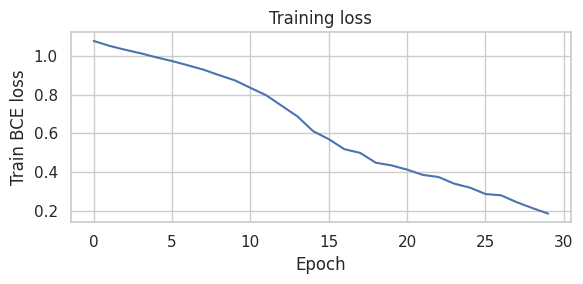

In [21]:
BATCH_SIZE = 4          # small on purpose -- this is a 21-patient train set
N_EPOCHS = 30
LEARNING_RATE = 1e-3

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

n_died_train = sum(patient_records[i]["label"] for i in train_ids)
n_survived_train = len(train_ids) - n_died_train
pos_weight_value = n_survived_train / max(n_died_train, 1)   # Part 8.3's cost-sensitive choice
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)
print(f"pos_weight = {pos_weight_value:.2f}  ({n_survived_train:.0f} survived / {n_died_train:.0f} died in train)")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        static_x = batch["static"].to(DEVICE)
        system_x = {k: v.to(DEVICE) for k, v in batch["systems"].items()}
        labels = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(static_x, system_x)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(labels)
    epoch_loss /= len(train_dataset)
    train_losses.append(epoch_loss)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS}  loss = {epoch_loss:.4f}")

plt.figure(figsize=(6, 3))
plt.plot(train_losses)
plt.xlabel("Epoch"); plt.ylabel("Train BCE loss"); plt.title("Training loss")
plt.tight_layout(); plt.show()

Test set predictions:
  100528073  true=0  predicted_prob=0.479
  100022051  true=0  predicted_prob=0.239
  100021152  true=0  predicted_prob=0.130
  100016720  true=0  predicted_prob=0.115
  100030433  true=0  predicted_prob=0.095
  100316372  true=1  predicted_prob=0.504
  100026753  true=0  predicted_prob=0.105
  100221250  true=0  predicted_prob=0.285
  100403813  true=1  predicted_prob=0.167

AUROC = 0.7857   AUPRC = 0.7000   Brier score = 0.1507
(On a ~9-patient test fold these numbers move by ~0.1-0.2 per single prediction -- repo's own documented finding. Not meaningful until run at scale.)


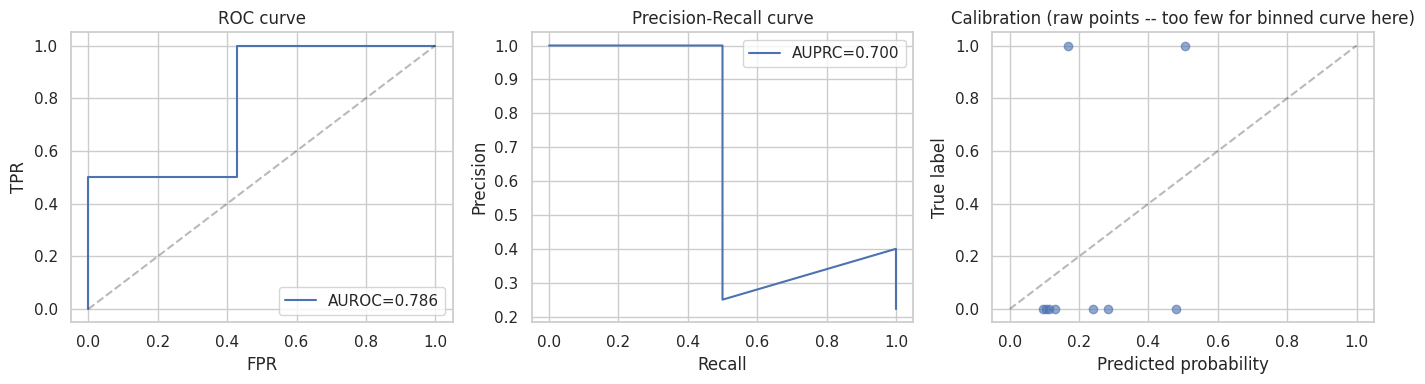

In [22]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, brier_score_loss

model.eval()
with torch.no_grad():
    batch = next(iter(test_loader))
    static_x = batch["static"].to(DEVICE)
    system_x = {k: v.to(DEVICE) for k, v in batch["systems"].items()}
    labels = batch["label"].numpy()
    logits, gate_weights, embeddings = model(static_x, system_x, return_gate=True)
    probs = torch.sigmoid(logits).cpu().numpy()

print("Test set predictions:")
for sid, y, p in zip(batch["subject_id"], labels, probs):
    print(f"  {sid}  true={int(y)}  predicted_prob={p:.3f}")

if len(set(labels)) > 1:
    auroc = roc_auc_score(labels, probs)
    auprc = average_precision_score(labels, probs)
    brier = brier_score_loss(labels, probs)
    print(f"\nAUROC = {auroc:.4f}   AUPRC = {auprc:.4f}   Brier score = {brier:.4f}")
    print("(On a ~9-patient test fold these numbers move by ~0.1-0.2 per single "
          "prediction -- repo's own documented finding. Not meaningful until run at scale.)")

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fpr, tpr, _ = roc_curve(labels, probs)
    axes[0].plot(fpr, tpr, label=f"AUROC={auroc:.3f}"); axes[0].plot([0,1],[0,1],'k--',alpha=0.3)
    axes[0].set_title("ROC curve"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].legend()

    prec, rec, _ = precision_recall_curve(labels, probs)
    axes[1].plot(rec, prec, label=f"AUPRC={auprc:.3f}")
    axes[1].set_title("Precision-Recall curve"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].legend()

    # Calibration (Part 8.3) -- is a predicted 0.3 really ~30%? Coarse-binned given tiny n.
    axes[2].scatter(probs, labels, alpha=0.6)
    axes[2].plot([0,1],[0,1],'k--',alpha=0.3)
    axes[2].set_title("Calibration (raw points -- too few for binned curve here)")
    axes[2].set_xlabel("Predicted probability"); axes[2].set_ylabel("True label")
    plt.tight_layout(); plt.show()
else:
    print("\nOnly one class present in this test fold -- AUROC undefined. "
          "This is exactly the small-sample instability Part 8 warns about; "
          "re-run with a different RANDOM_SEED or, better, on the full dataset.")

In [23]:
# ── Interpretability check: which system did the gate weight most, per patient? (Part 9.3) ──
gate_df = pd.DataFrame({name: w.detach().cpu().numpy() for name, w in gate_weights.items()},
                        index=batch["subject_id"])
gate_df["true_label"] = labels
gate_df["predicted_prob"] = probs
print("Per-patient gate weights (how much each branch contributed to the fused embedding):")
gate_df.style.background_gradient(cmap="Reds", subset=[c for c in gate_df.columns if c not in ("true_label",)])

Per-patient gate weights (how much each branch contributed to the fused embedding):


,renal,cardiovascular,respiratory,metabolic_hepatic,haematology,neurological,gastrointestinal,musculoskeletal,static,true_label,predicted_prob
100528073,0.089370,0.007152,0.885952,0.000746,0.001279,0.002184,0.000722,0.000732,0.011862,0.000000,0.478572
100022051,0.136477,0.013564,0.684588,0.005517,0.010631,0.083964,0.006954,0.006076,0.052229,0.000000,0.239262
100021152,0.000150,0.000000,0.999843,0.000000,0.000000,0.000001,0.000000,0.000000,0.000005,0.000000,0.130120
100016720,0.030068,0.002442,0.937323,0.000838,0.001557,0.011122,0.001594,0.000873,0.014184,0.000000,0.114673
100030433,0.005797,0.000205,0.991557,0.000033,0.000083,0.000646,0.000102,0.000039,0.001538,0.000000,0.095393
100316372,0.346294,0.019937,0.612294,0.001151,0.002331,0.005596,0.001216,0.001149,0.010033,1.000000,0.504093
100026753,0.041800,0.002429,0.935641,0.000507,0.001030,0.006964,0.000888,0.000536,0.010205,0.000000,0.104633
100221250,0.262544,0.018435,0.587139,0.005544,0.007828,0.076206,0.004577,0.004452,0.033274,0.000000,0.284725
100403813,0.097812,0.008268,0.787865,0.003196,0.005911,0.053577,0.003946,0.003147,0.036279,1.000000,0.167446


## Part 13 — Interpretability and next experiments

**What this notebook gives you that the single-transformer baseline doesn't:**
- A per-patient breakdown of which organ system (including the two new branches, GI and
  musculoskeletal) the gate weighted most heavily — directly inspectable in the table
  above, not a post-hoc SHAP approximation.
- An explicit, learned cardio-renal interaction term, separable from "both happened to be
  abnormal."
- Operation-history features that encode *same-area* recurrence and the *cardiovascular
  washout exception*, not just a raw operation count.
- Three separate time windows per system (pre/intra/post-op), so window-ablation is a
  one-line experiment (zero out one window's tensor, re-run inference, see how much the
  prediction moves).

**Concrete next experiments, in priority order — each one is a natural continuation of a
reasoning thread opened above, not a new direction:**

1. **Run this notebook against the full ~99,886-patient dataset once mounted** (one config
   line, Part 1) — everything above is a pipeline validated on 30 patients, not a result.
2. **Confirm the full-dataset 30-day death count** (repo's own priority-1 item) before
   trusting `pos_weight` at scale.
3. **Window ablation** — mask each of preop/intraop/postop in turn, compare AUROC, to
   answer Part 6.3's "how much is each window actually contributing" question with real
   numbers instead of reasoning alone.
4. **Validate the cardiac washout threshold empirically** (Part 6.2) — once real volume
   of cardiac-then-reoperation cases exists, check whether outcomes for the <180-day
   group are measurably worse, and whether 180 days is the data-supported threshold.
5. **A/B the missing-data strategy** — median-fill (this notebook) vs. a masked-value
   pre-training objective (Part 7.3) vs. MICE, on the same train/test split, same model.
6. **A/B the class-imbalance strategy** — plain `pos_weight` (this notebook) vs. focal
   loss vs. SMOTE-on-static-features-only (Part 8.3), same split, same model.
7. **Swap `encoder_type='transformer'`** (Part 9.2) once more data makes a heavier
   per-branch model viable, and compare against the GRU default.
8. **Add the Concept Bottleneck layer** (Part 9.6) once clinician-confirmed staging
   thresholds (AKI via KDIGO, respiratory failure via Berlin criteria) are available —
   the natural next interpretability layer on top of this gated-fusion base.
9. **Move ICD-10 features from chapter-level multi-hot to a learned Med2Vec/GRAM-style
   embedding** (Part 9.4) once enough unlabelled volume exists to train it properly.
10. **Benchmark against Shickel et al. 2023** (AUROC 0.92, 56,242 patients) once items
    1–2 are settled — the eventual headline comparison.

## Part 14 — References

**Dataset**
- Lee, H.-C. et al. (2024). "A large-scale, high-quality, multi-institutional clinical
  time-series database with reproducible outcome tasks: the INSPIRE dataset." *Scientific
  Data*. doi:10.1038/s41597-024-03517-4.

**Missing data (Part 7)**
- Rubin, D.B. (1976). "Inference and Missing Data." *Biometrika*, 63(3), 581–592.
- Van Buuren, S. & Groothuis-Oudshoorn, K. (2011). "mice: Multivariate Imputation by
  Chained Equations in R." *Journal of Statistical Software*, 45(3).
- Yoon, J., Jordon, J., & van der Schaar, M. (2018). "GAIN: Missing Data Imputation using
  Generative Adversarial Nets." *ICML*.

**Class imbalance and sampling (Part 8)**
- Chawla, N.V., Bowyer, K.W., Hall, L.O., & Kegelmeyer, W.P. (2002). "SMOTE: Synthetic
  Minority Over-sampling Technique." *Journal of Artificial Intelligence Research*, 16,
  321–357.
- He, H., Bai, Y., Garcia, E.A., & Li, S. (2008). "ADASYN: Adaptive synthetic sampling
  approach for imbalanced learning." *IEEE IJCNN*.
- Lin, T.-Y., Goyal, P., Girshick, R., He, K., & Dollár, P. (2017). "Focal Loss for Dense
  Object Detection." *ICCV*.

**Multimodal / clinical time-series architecture (Part 9)**
- Choi, E., Bahadori, M.T., Searles, E., et al. (2016). "Multi-layer Representation
  Learning for Medical Concepts" (Med2Vec). *KDD*.
- Choi, E., Bahadori, M.T., Song, L., Stewart, W.F., & Sun, J. (2017). "GRAM: Graph-based
  Attention Model for Healthcare Representation Learning." *KDD*. arXiv:1611.07012.
- Choi, E., Bahadori, M.T., Sun, J., Kulas, J., Schuetz, A., & Stewart, W. (2016).
  "RETAIN: An Interpretable Predictive Model for Healthcare using Reverse Time Attention
  Mechanism." *NeurIPS*.
- Koh, P.W. et al. (2020). "Concept Bottleneck Models." *ICML*.
- Bento, J. et al. (2021). "TimeSHAP: Explaining Recurrent Models through Sequence
  Perturbations." *KDD*.
- Shickel, B. et al. (2023). "Deep multi-modal transfer learning for augmented
  patient acuity assessment in the intelligent ICU." *Scientific Reports*.
  doi:10.1038/s41598-023-27418-5. — closest published benchmark for this task
  (56,242 patients, AUROC 0.92).

**Clinical scoring systems and organ-system taxonomy (Part 5)**
- Vincent, J.-L. et al. (1996). "The SOFA (Sepsis-related Organ Failure Assessment)
  score to describe organ dysfunction/failure." *Intensive Care Medicine*.
- Singer, M. et al. (2016). "The Third International Consensus Definitions for Sepsis
  and Septic Shock (Sepsis-3)." *JAMA*, 315(8), 801–810.
- Ronco, C., Haapio, M., House, A.A., Anavekar, N., & Bellomo, R. (2008). "Cardiorenal
  Syndrome." *Journal of the American College of Cardiology*, 52(19), 1527–1539. —
  primary reference for the renal↔cardiovascular coupling design (Part 5.4).
- Copeland, G.P. et al. (1991). POSSUM — original 12-physiology + 6-operative-factor
  equation.
- Prytherch, D.R. et al. (1998). "Portsmouth-POSSUM (P-POSSUM)." *British Journal of
  Surgery*.
- Gilbert, T. et al. (2018). "Development and validation of a Hospital Frailty Risk
  Score focusing on older people in acute care settings using electronic hospital
  records: an observational study." *The Lancet*, 391(10132), 1775–1782.
- Agency for Healthcare Research and Quality (AHRQ), HCUP. *Clinical Classifications
  Software Refined (CCSR) for ICD-10-CM Diagnoses*. hcup-us.ahrq.gov/toolssoftware/ccsr/

**ICD-10-PCS reference**
- Centers for Medicare & Medicaid Services (CMS). *ICD-10-PCS Reference Manual* —
  official body-system letter table used in Part 5.3/10.1's `classify_icd10_pcs()`;
  worth confirming the exact letter table against this primary source before
  publication, consistent with the caution the source repo already applies to its
  own ICD-10-PCS claims.

*As with the citations already flagged as "needs confirming" throughout the source repo,
every reference above is a strong, genuine starting point for the literature — not a
substitute for verifying exact volume/page/DOI details before they go into a
manuscript.*